#  Marketing Mix Modeling (MMM): A Complete Guide
## From Theory to Implementation for Data Scientists

---

**Author's Note:** This notebook is designed to take you from zero to expert in Marketing Mix Modeling. We will cover the theoretical foundations, mathematical rigor, and practical implementation of MMM systems.

### What You Will Learn:
1. **Foundational Theory**: The science behind MMM, its history, and key concepts
2. **Mathematical Framework**: Adstock, saturation, and the complete MMM equation
3. **Implementation**: Building both frequentist and Bayesian MMM from scratch
4. **Advanced Topics**: Time-varying effects, and hierarchical models
5. **Business Applications**: ROI calculation, budget optimization, and scenario planning

### Prerequisites:
- Basic Python knowledge
- Familiarity with statistics (regression, probability distributions)
- Understanding of marketing concepts (helpful but not required)

---

**Estimated Time**: 4-6 hours for complete study

---

# Section 1: Import Required Libraries

Before we begin, we need to set up our Python environment with all the necessary libraries for data manipulation, statistical modeling, visualization, and Bayesian inference.

In [1]:
# Install required packages (run once)
# Uncomment and run if packages are not installed
# !pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-learn pymc arviz

import warnings
warnings.filterwarnings('ignore')

# Core data manipulation and numerical computing
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# Statistical modeling
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
from scipy.optimize import minimize, differential_evolution
from scipy.special import expit  # Sigmoid function

# Machine Learning
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Random seed for reproducibility
np.random.seed(42)

print(" All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

 All libraries imported successfully!
NumPy version: 2.4.1
Pandas version: 3.0.0


---

# Section 2: Understanding Marketing Mix Modeling - Theory and Mathematical Foundations

## 2.1 What is Marketing Mix Modeling?

**Marketing Mix Modeling (MMM)** is a statistical technique used to quantify the impact of marketing activities and other factors on a business outcome (typically sales, revenue, or conversions). It originates from **econometrics** and has been used since the 1960s to help businesses understand the effectiveness of their marketing investments.

### The Core Question MMM Answers:
> *"For every dollar spent on each marketing channel, how much additional revenue/sales did we generate?"*

### Historical Context:
- **1960s-1970s**: Origins in econometrics, pioneered by companies like Procter & Gamble
- **1980s-1990s**: Widespread adoption in CPG (Consumer Packaged Goods) industry
- **2000s-2010s**: Integration with digital channels, rise of Multi-Touch Attribution (MTA)
- **2020s**: Renaissance of MMM due to privacy changes (iOS 14.5, cookie deprecation), Bayesian approaches, and open-source tools

---

## 2.2 The Fundamental MMM Equation

The core mathematical framework of MMM is a **multiple regression model** with special transformations:

$$Y_t = \beta_0 + \sum_{i=1}^{M} \beta_i \cdot f(X_{i,t}) + \sum_{j=1}^{K} \gamma_j \cdot Z_{j,t} + \epsilon_t$$

Where:
- $Y_t$ = **Outcome variable** at time $t$ (sales, revenue, conversions)
- $\beta_0$ = **Intercept/Baseline** (sales without any marketing)
- $X_{i,t}$ = **Marketing variable** $i$ at time $t$ (spend, impressions, GRPs)
- $f(\cdot)$ = **Transformation function** (adstock + saturation)
- $\beta_i$ = **Coefficient** for marketing variable $i$ (effect size)
- $Z_{j,t}$ = **Control variable** $j$ at time $t$ (seasonality, price, promotions, economy)
- $\gamma_j$ = **Coefficient** for control variable $j$
- $\epsilon_t$ = **Error term** ~ $N(0, \sigma^2)$

---

## 2.3 Key Components Explained

### 1. **Baseline ($\beta_0$)**
The sales you would achieve with zero marketing. This represents:
- Brand equity / organic demand
- Repeat purchases from existing customers
- Word-of-mouth effects

### 2. **Media Transformations $f(\cdot)$**
Marketing channels don't affect sales linearly or instantaneously. We apply two key transformations:

a) **Adstock (Carryover)**: Captures the lagged effect of advertising
   - Advertising seen today still influences purchases tomorrow, next week, etc.
   
b) **Saturation (Diminishing Returns)**: Captures decreasing marginal returns
   - Doubling ad spend doesn't double the sales impact

### 3. **Control Variables ($Z_j$)**
Factors that affect sales but aren't marketing:
- **Trend**: Long-term growth or decline
- **Seasonality**: Weekly, monthly, annual patterns
- **Price**: Your product's price
- **Promotions**: Discounts, sales events
- **Competitor Activity**: Competitor pricing/advertising
- **External Factors**: Economy, weather, COVID, etc.

---

## 2.4 MMM vs. Multi-Touch Attribution (MTA)

| Aspect | MMM | MTA |
|--------|-----|-----|
| **Data Level** | Aggregate (weekly/daily totals) | Individual user journeys |
| **Channels** | All (including radio, digital, OOH) | Digital only |
| **Privacy Impact** | Minimal (no user-level data) | Significant (cookies, IDFA) |
| **Time Horizon** | Long-term effects | Short-term touchpoints |
| **Methodology** | Regression/Bayesian modeling | Rule-based or ML attribution |
| **Incrementality** | Can measure (with holdout) | Hard to measure |

**Key Insight**: MMM is making a comeback because it's privacy-safe and can measure offline channels. Many companies now use **triangulation** - combining MMM, MTA, and experiments.

---

## 2.5 Key Assumptions of MMM

For valid MMM results, we assume:

1. **Linearity** (in parameters): The relationship between transformed inputs and output is linear
2. **No Perfect Multicollinearity**: Marketing channels aren't perfectly correlated
3. **Exogeneity**: Error terms are uncorrelated with predictors
4. **Homoscedasticity**: Constant variance of residuals
5. **No Autocorrelation**: Residuals aren't correlated over time (often violated in time series)
6. **Correct Specification**: We've included all relevant variables

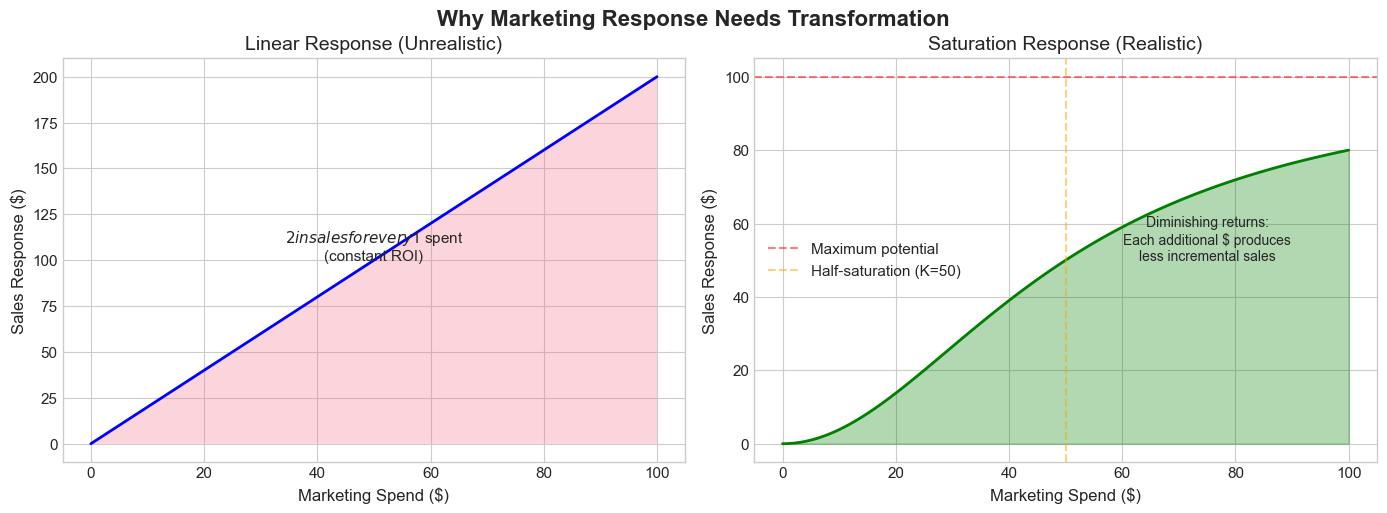


 Key Insight: Real marketing channels show diminishing returns.
   Spending $100 doesn't give 2x the impact of spending $50.


In [2]:
# Visualize a simple marketing response curve to illustrate the concept
# This shows why we need transformations

# Generate sample data
spend_levels = np.linspace(0, 100, 100)

# Linear response (unrealistic)
linear_response = 2 * spend_levels

# Realistic response with diminishing returns (Hill function)
K = 50  # Half-saturation point
alpha = 2  # Shape parameter
saturation_response = 100 * (spend_levels ** alpha) / (K ** alpha + spend_levels ** alpha)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear response
axes[0].plot(spend_levels, linear_response, 'b-', linewidth=2)
axes[0].set_xlabel('Marketing Spend ($)')
axes[0].set_ylabel('Sales Response ($)')
axes[0].set_title('Linear Response (Unrealistic)', fontsize=14)
axes[0].fill_between(spend_levels, linear_response, alpha=0.3)
axes[0].annotate('$2 in sales for every $1 spent\n(constant ROI)', 
                xy=(50, 100), fontsize=11, ha='center')

# Saturation response
axes[1].plot(spend_levels, saturation_response, 'g-', linewidth=2)
axes[1].axhline(y=100, color='r', linestyle='--', alpha=0.5, label='Maximum potential')
axes[1].axvline(x=K, color='orange', linestyle='--', alpha=0.5, label=f'Half-saturation (K={K})')
axes[1].set_xlabel('Marketing Spend ($)')
axes[1].set_ylabel('Sales Response ($)')
axes[1].set_title('Saturation Response (Realistic)', fontsize=14)
axes[1].fill_between(spend_levels, saturation_response, alpha=0.3, color='green')
axes[1].legend()
axes[1].annotate('Diminishing returns:\nEach additional $ produces\nless incremental sales', 
                xy=(75, 50), fontsize=10, ha='center')

plt.tight_layout()
plt.suptitle('Why Marketing Response Needs Transformation', y=1.02, fontsize=16, fontweight='bold')
plt.show()

print("\n Key Insight: Real marketing channels show diminishing returns.")
print("   Spending $100 doesn't give 2x the impact of spending $50.")

---

# Section 3: Load and Explore the Dataset

For this tutorial, we'll generate a realistic simulated marketing dataset. This approach has several advantages:
1. **Reproducibility**: Anyone can run this notebook without downloading data
2. **Ground Truth**: We know the true parameters, allowing us to validate our model
3. **Realistic Patterns**: We'll include seasonality, carryover effects, and saturation

The dataset simulates a business with:
- **3 Marketing Channels**: Radio, Digital, Social Media
- **Weekly Data**: 3 years (156 weeks)
- **Realistic Effects**: Including trend, seasonality, and holidays

In [3]:
def generate_mmm_dataset(n_weeks=156, seed=42):
    """
    Generate a realistic marketing dataset with known ground truth parameters.
    
    This simulates a business with 4 marketing channels over 3 years.
    """
    np.random.seed(seed)
    
    # Time index
    dates = pd.date_range(start='2022-01-03', periods=n_weeks, freq='W-MON')
    
    # ========== MARKETING SPEND DATA ==========
    # Generate correlated spend (channels often move together due to campaigns)
    
    # Base spend patterns
    radio_spend = np.random.lognormal(mean=2.5, sigma=0.4, size=n_weeks) * 500
    digital_spend = np.random.lognormal(mean=3.0, sigma=0.6, size=n_weeks) * 800
    social_spend = np.random.lognormal(mean=2.8, sigma=0.5, size=n_weeks) * 600
    
    # Add some campaign spikes (coordinated marketing pushes)
    campaign_weeks = [10, 25, 40, 60, 80, 100, 120, 145]
    for week in campaign_weeks:
        if week < n_weeks:
            digital_spend[week:week+3] *= 1.8
            social_spend[week:week+3] *= 1.5
    
    # ========== TRUE PARAMETERS (GROUND TRUTH) ==========
    # These are the parameters we'll try to recover
    
    TRUE_PARAMS = {
        'baseline': 50000,  # Baseline sales (no marketing)
        'trend': 50,        # Weekly trend (growth)
        
        # Adstock decay rates (0 = no carryover, 1 = infinite carryover)
        'radio_decay': 0.4,
        'digital_decay': 0.3,
        'social_decay': 0.5,
        
        # Saturation parameters (Hill function)
        # K = half-saturation point, alpha = shape
        'radio_K': 15000, 'radio_alpha': 2.0,
        'digital_K': 30000, 'digital_alpha': 1.8,
        'social_K': 20000, 'social_alpha': 2.2,
        
        # Effect sizes (contribution to sales)
        'radio_beta': 8000,
        'digital_beta': 12000,
        'social_beta': 6000,
        
        # Seasonality amplitude
        'seasonality_amp': 5000,
        
        # Noise standard deviation
        'noise_std': 3000
    }
    
    # ========== APPLY ADSTOCK TRANSFORMATION ==========
    def apply_adstock(x, decay):
        """Geometric adstock transformation"""
        adstocked = np.zeros_like(x)
        adstocked[0] = x[0]
        for i in range(1, len(x)):
            adstocked[i] = x[i] + decay * adstocked[i-1]
        return adstocked
    
    radio_adstock = apply_adstock(radio_spend, TRUE_PARAMS['radio_decay'])
    digital_adstock = apply_adstock(digital_spend, TRUE_PARAMS['digital_decay'])
    social_adstock = apply_adstock(social_spend, TRUE_PARAMS['social_decay'])
    
    # ========== APPLY SATURATION (HILL FUNCTION) ==========
    def hill_function(x, K, alpha):
        """Hill saturation function"""
        return x ** alpha / (K ** alpha + x ** alpha)
    
    radio_saturated = hill_function(radio_adstock, TRUE_PARAMS['radio_K'], TRUE_PARAMS['radio_alpha'])
    digital_saturated = hill_function(digital_adstock, TRUE_PARAMS['digital_K'], TRUE_PARAMS['digital_alpha'])
    social_saturated = hill_function(social_adstock, TRUE_PARAMS['social_K'], TRUE_PARAMS['social_alpha'])
    
    # ========== GENERATE CONTROL VARIABLES ==========
    # Trend component
    trend = TRUE_PARAMS['trend'] * np.arange(n_weeks)
    
    # Seasonality (annual cycle)
    week_of_year = np.array([d.isocalendar()[1] for d in dates])
    seasonality = TRUE_PARAMS['seasonality_amp'] * np.sin(2 * np.pi * week_of_year / 52)
    
    # Holiday effects (higher sales in Q4)
    holidays = np.zeros(n_weeks)
    for i, d in enumerate(dates):
        if d.month in [11, 12]:  # November, December
            holidays[i] = 8000
        elif d.month in [1]:  # Post-holiday dip
            holidays[i] = -3000
    
    # ========== CALCULATE SALES (GROUND TRUTH) ==========
    sales = (
        TRUE_PARAMS['baseline'] +
        trend +
        seasonality +
        holidays +
        TRUE_PARAMS['radio_beta'] * radio_saturated +
        TRUE_PARAMS['digital_beta'] * digital_saturated +
        TRUE_PARAMS['social_beta'] * social_saturated +
        np.random.normal(0, TRUE_PARAMS['noise_std'], n_weeks)
    )
    
    # Ensure non-negative sales
    sales = np.maximum(sales, 0)
    
    # ========== CREATE DATAFRAME ==========
    df = pd.DataFrame({
        'date': dates,
        'week': np.arange(n_weeks),
        'sales': sales,
        'radio_spend': radio_spend,
        'digital_spend': digital_spend,
        'social_spend': social_spend,
        'holidays': holidays,
        'week_of_year': week_of_year
    })
    
    return df, TRUE_PARAMS

# Generate the dataset
df, TRUE_PARAMS = generate_mmm_dataset(n_weeks=156)

print("=" * 60)
print(" MARKETING MIX MODELING DATASET GENERATED")
print("=" * 60)
print(f"\nDataset Shape: {df.shape}")
print(f"Date Range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"\nTotal Weeks: {len(df)}")
print(f"Total Sales: ${df['sales'].sum():,.0f}")
print(f"Total Marketing Spend: ${df[['radio_spend', 'digital_spend', 'social_spend']].sum().sum():,.0f}")

print("\n" + "=" * 60)
print(" FIRST 10 ROWS OF DATA")
print("=" * 60)
df.head(10)

 MARKETING MIX MODELING DATASET GENERATED

Dataset Shape: (156, 8)
Date Range: 2022-01-03 to 2024-12-23

Total Weeks: 156
Total Sales: $10,374,477
Total Marketing Spend: $6,438,600

 FIRST 10 ROWS OF DATA


,date,week,sales,radio_spend,digital_spend,social_spend,holidays,week_of_year
0,2022-01-03,0,58159.764326,7430.093781,49221.039065,14907.769958,-3000.0,1
1,2022-01-10,1,58891.870041,5763.512506,21352.230371,14819.282349,-3000.0,2
2,2022-01-17,2,58827.075671,7892.620703,7862.261993,18952.081739,-3000.0,3
3,2022-01-24,3,56385.772242,11201.691145,23826.266674,9970.954305,-3000.0,4
4,2022-01-31,4,55823.442972,5546.635177,8953.526227,13875.863083,-3000.0,5
5,2022-02-07,5,69679.400580,5546.671603,25767.324859,8448.940069,0.0,6
6,2022-02-14,6,74210.179995,11456.278790,32201.524498,11602.928840,0.0,7
7,2022-02-21,7,65089.794167,8279.865391,9820.254688,9245.184756,0.0,8
8,2022-02-28,8,69276.823585,5048.358117,28642.227824,10357.100869,0.0,9
9,2022-03-07,9,68897.662411,7567.606513,20584.224982,13286.558551,0.0,10


In [5]:
# Display the TRUE parameters (ground truth) that we will try to recover
print("=" * 60)
print(" TRUE PARAMETERS (GROUND TRUTH)")
print("=" * 60)
print("\nThese are the actual parameters used to generate the data.")
print("Our MMM should recover values close to these.\n")

for key, value in TRUE_PARAMS.items():
    print(f"  {key:20s}: {value}")
    
print("\n" + "=" * 60)

 TRUE PARAMETERS (GROUND TRUTH)

These are the actual parameters used to generate the data.
Our MMM should recover values close to these.

  baseline            : 50000
  trend               : 50
  radio_decay         : 0.4
  digital_decay       : 0.3
  social_decay        : 0.5
  radio_K             : 15000
  radio_alpha         : 2.0
  digital_K           : 30000
  digital_alpha       : 1.8
  social_K            : 20000
  social_alpha        : 2.2
  radio_beta          : 8000
  digital_beta        : 12000
  social_beta         : 6000
  seasonality_amp     : 5000
  noise_std           : 3000



## 3.1 Exploratory Data Analysis (EDA)

Before building any model, we must thoroughly understand our data. Key questions:
1. What are the distributions of our variables?
2. Are there trends or seasonality in sales?
3. How correlated are our marketing channels?
4. Are there outliers or anomalies?

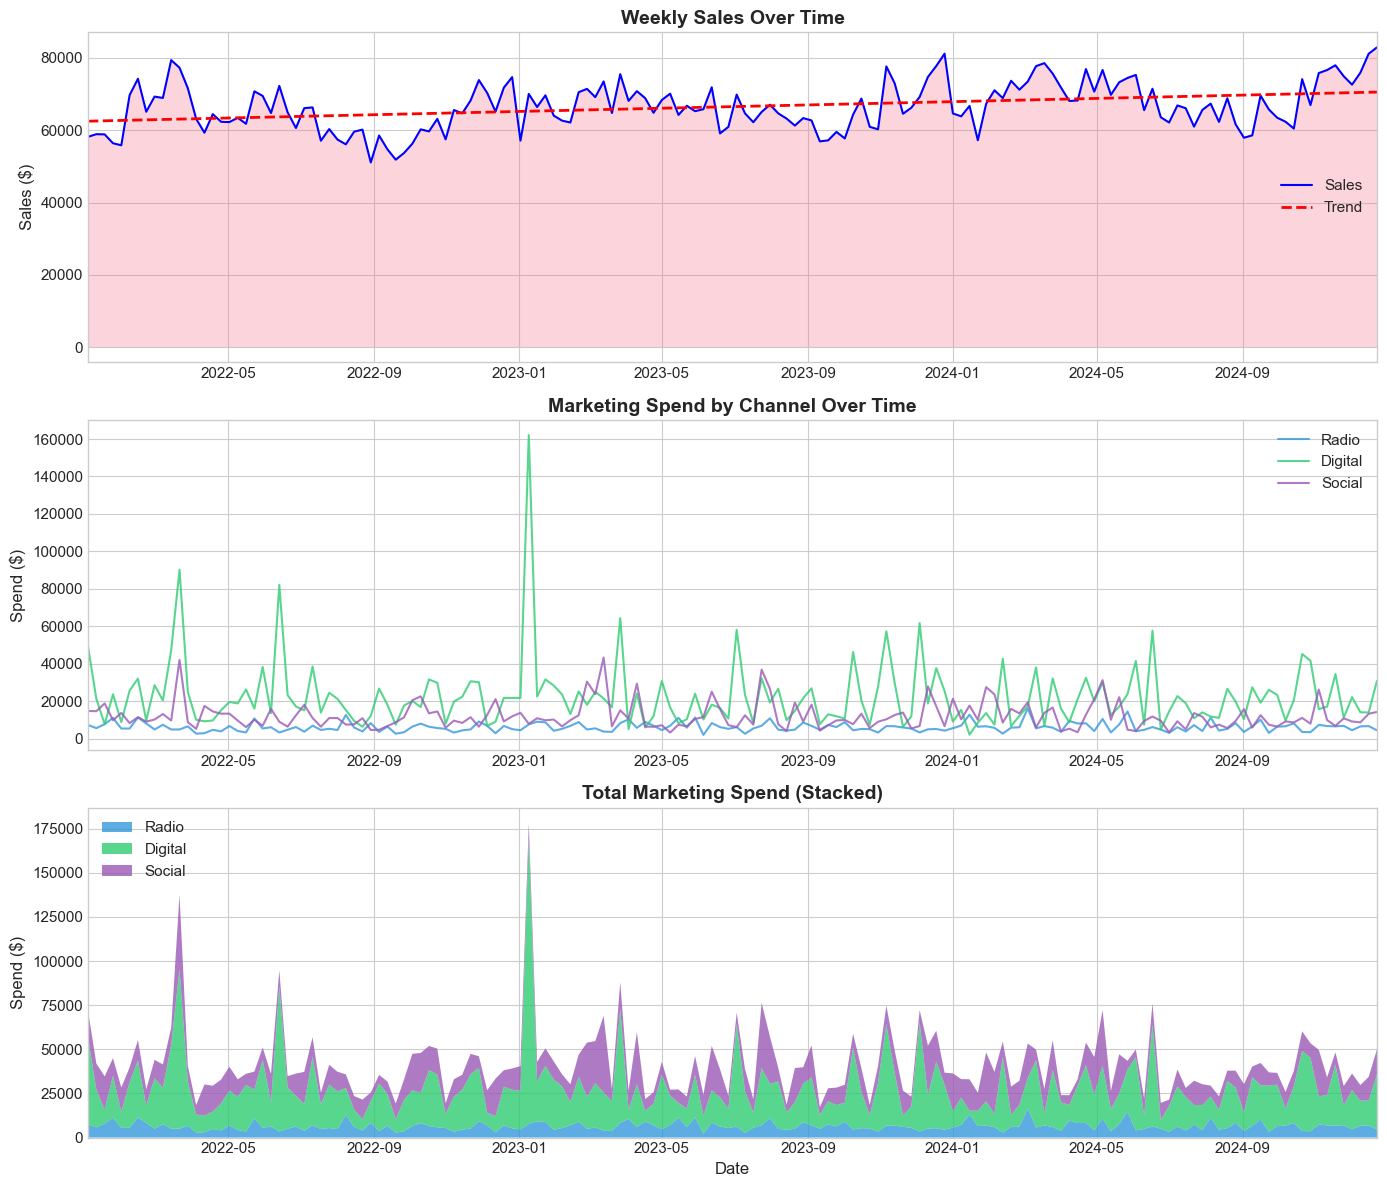


 SUMMARY STATISTICS
          sales  radio_spend  digital_spend  social_spend
count    156.00       156.00         156.00        156.00
mean   66503.06      6317.25       22722.90      12232.92
std     6588.88      2438.28       18044.79       7136.73
min    51085.11      2136.04        2298.13       3411.75
25%    62028.08      4644.92       12001.16       7525.26
50%    65925.87      6005.92       19383.24      10243.56
75%    71061.93      7210.23       26813.67      13970.40
max    82889.86     16316.06      162145.70      43433.49


In [6]:
# Time Series Plot: Sales and Marketing Spend Over Time
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Sales over time
axes[0].plot(df['date'], df['sales'], 'b-', linewidth=1.5, label='Sales')
axes[0].fill_between(df['date'], df['sales'], alpha=0.3)
axes[0].set_ylabel('Sales ($)')
axes[0].set_title('Weekly Sales Over Time', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(df['date'].min(), df['date'].max())

# Add trend line
z = np.polyfit(range(len(df)), df['sales'], 1)
p = np.poly1d(z)
axes[0].plot(df['date'], p(range(len(df))), 'r--', linewidth=2, label='Trend')
axes[0].legend()

# Marketing spend over time
colors = {'radio_spend': '#3498db', 
          'digital_spend': '#2ecc71', 'social_spend': '#9b59b6'}
for channel, color in colors.items():
    axes[1].plot(df['date'], df[channel], label=channel.replace('_spend', '').title(), 
                 linewidth=1.5, color=color, alpha=0.8)
axes[1].set_ylabel('Spend ($)')
axes[1].set_title('Marketing Spend by Channel Over Time', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].set_xlim(df['date'].min(), df['date'].max())

# Stacked area chart of spend
spend_cols = ['radio_spend', 'digital_spend', 'social_spend']
axes[2].stackplot(df['date'], [df[col] for col in spend_cols], 
                  labels=[c.replace('_spend', '').title() for c in spend_cols],
                  colors=[colors[c] for c in spend_cols], alpha=0.8)
axes[2].set_ylabel('Spend ($)')
axes[2].set_xlabel('Date')
axes[2].set_title('Total Marketing Spend (Stacked)', fontsize=14, fontweight='bold')
axes[2].legend(loc='upper left')
axes[2].set_xlim(df['date'].min(), df['date'].max())

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n SUMMARY STATISTICS")
print("=" * 70)
print(df[['sales', 'radio_spend', 'digital_spend', 'social_spend']].describe().round(2).to_string())

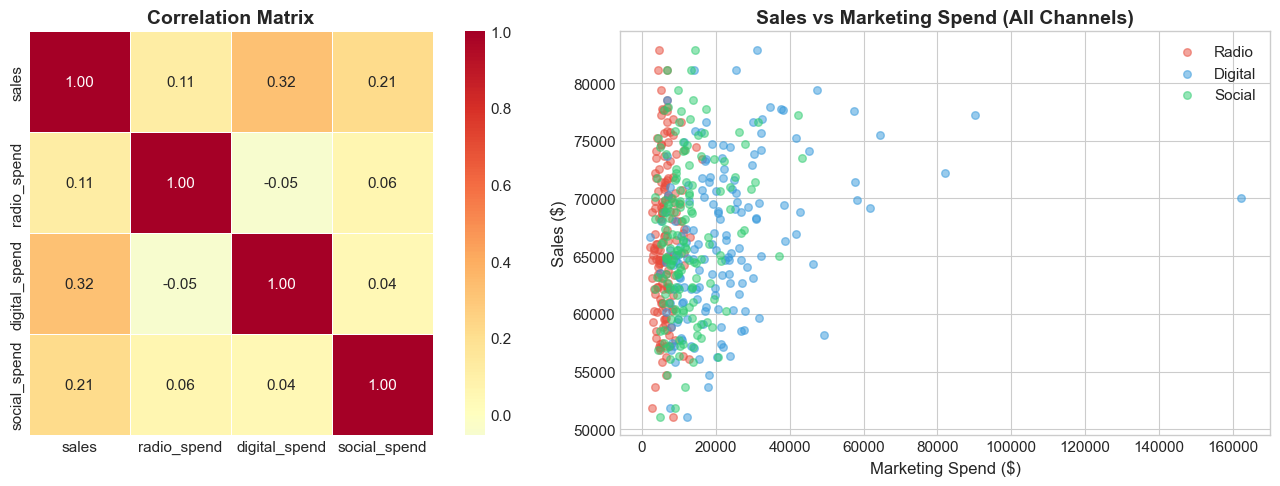


  MULTICOLLINEARITY CHECK

Correlation between channels:
  radio_spend ↔ digital_spend: -0.053
  radio_spend ↔ social_spend: 0.064
  digital_spend ↔ social_spend: 0.044

 No severe multicollinearity detected (all correlations < 0.7)


In [7]:
# Correlation Analysis - Critical for understanding multicollinearity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation matrix
corr_cols = ['sales', 'radio_spend', 'digital_spend', 'social_spend']
corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, 
            ax=axes[0], fmt='.2f', square=True, linewidths=0.5)
axes[0].set_title('Correlation Matrix', fontsize=14, fontweight='bold')

# Pairplot-style scatter (Sales vs each channel)
spend_cols = ['radio_spend', 'digital_spend', 'social_spend']
colors_list = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

for i, (col, color) in enumerate(zip(spend_cols, colors_list)):
    axes[1].scatter(df[col], df['sales'], alpha=0.5, c=color, 
                   label=col.replace('_spend', '').title(), s=30)

axes[1].set_xlabel('Marketing Spend ($)')
axes[1].set_ylabel('Sales ($)')
axes[1].set_title('Sales vs Marketing Spend (All Channels)', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Check for multicollinearity using VIF would be done here
print("\n  MULTICOLLINEARITY CHECK")
print("=" * 60)
print("\nCorrelation between channels:")
channel_corr = df[spend_cols].corr()
for i in range(len(spend_cols)):
    for j in range(i+1, len(spend_cols)):
        print(f"  {spend_cols[i]} ↔ {spend_cols[j]}: {channel_corr.iloc[i,j]:.3f}")

high_corr = (channel_corr.abs() > 0.7) & (channel_corr != 1.0)
if high_corr.any().any():
    print("\n  WARNING: High correlation detected between some channels!")
    print("   This may cause multicollinearity issues in the model.")
else:
    print("\n No severe multicollinearity detected (all correlations < 0.7)")

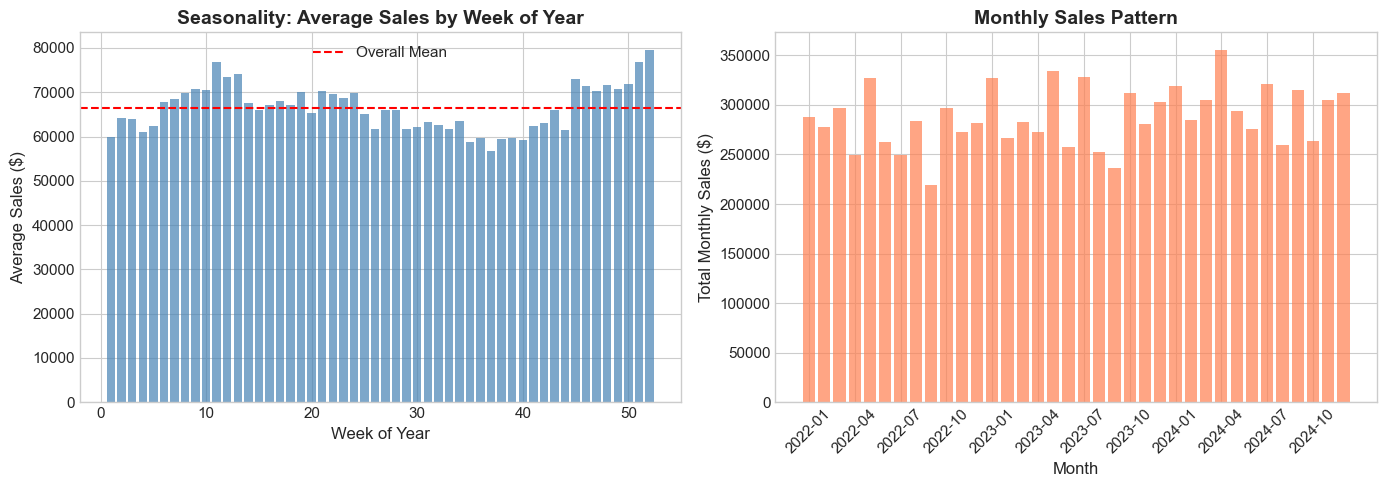


 SEASONALITY INSIGHTS
Highest sales week: Week 52 ($79,558)
Lowest sales week: Week 37 ($56,728)
Seasonality range: $22,830


In [8]:
# Seasonality Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales by week of year (seasonality pattern)
weekly_sales = df.groupby('week_of_year')['sales'].mean()
axes[0].bar(weekly_sales.index, weekly_sales.values, color='steelblue', alpha=0.7)
axes[0].axhline(y=df['sales'].mean(), color='red', linestyle='--', label='Overall Mean')
axes[0].set_xlabel('Week of Year')
axes[0].set_ylabel('Average Sales ($)')
axes[0].set_title('Seasonality: Average Sales by Week of Year', fontsize=14, fontweight='bold')
axes[0].legend()

# Monthly aggregation
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
monthly = df.groupby(['year', 'month'])['sales'].sum().reset_index()
monthly['period'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)

axes[1].bar(range(len(monthly)), monthly['sales'], color='coral', alpha=0.7)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Monthly Sales ($)')
axes[1].set_title('Monthly Sales Pattern', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(0, len(monthly), 3))
axes[1].set_xticklabels(monthly['period'].iloc[::3], rotation=45)

plt.tight_layout()
plt.show()

print("\n SEASONALITY INSIGHTS")
print("=" * 60)
print(f"Highest sales week: Week {weekly_sales.idxmax()} (${weekly_sales.max():,.0f})")
print(f"Lowest sales week: Week {weekly_sales.idxmin()} (${weekly_sales.min():,.0f})")
print(f"Seasonality range: ${weekly_sales.max() - weekly_sales.min():,.0f}")

---

# Section 4: Data Preprocessing and Feature Engineering

Before modeling, we need to:
1. Handle any data quality issues
2. Create control variables (trend, seasonality features)
3. Split data into training and holdout sets
4. Scale variables appropriately

**Important**: In MMM, we typically hold out the most recent 10-20% of data for validation. This simulates predicting future performance.

 DATA QUALITY CHECK

Missing values:
date             0
week             0
sales            0
radio_spend      0
digital_spend    0
social_spend     0
holidays         0
week_of_year     0
month            0
year             0
dtype: int64


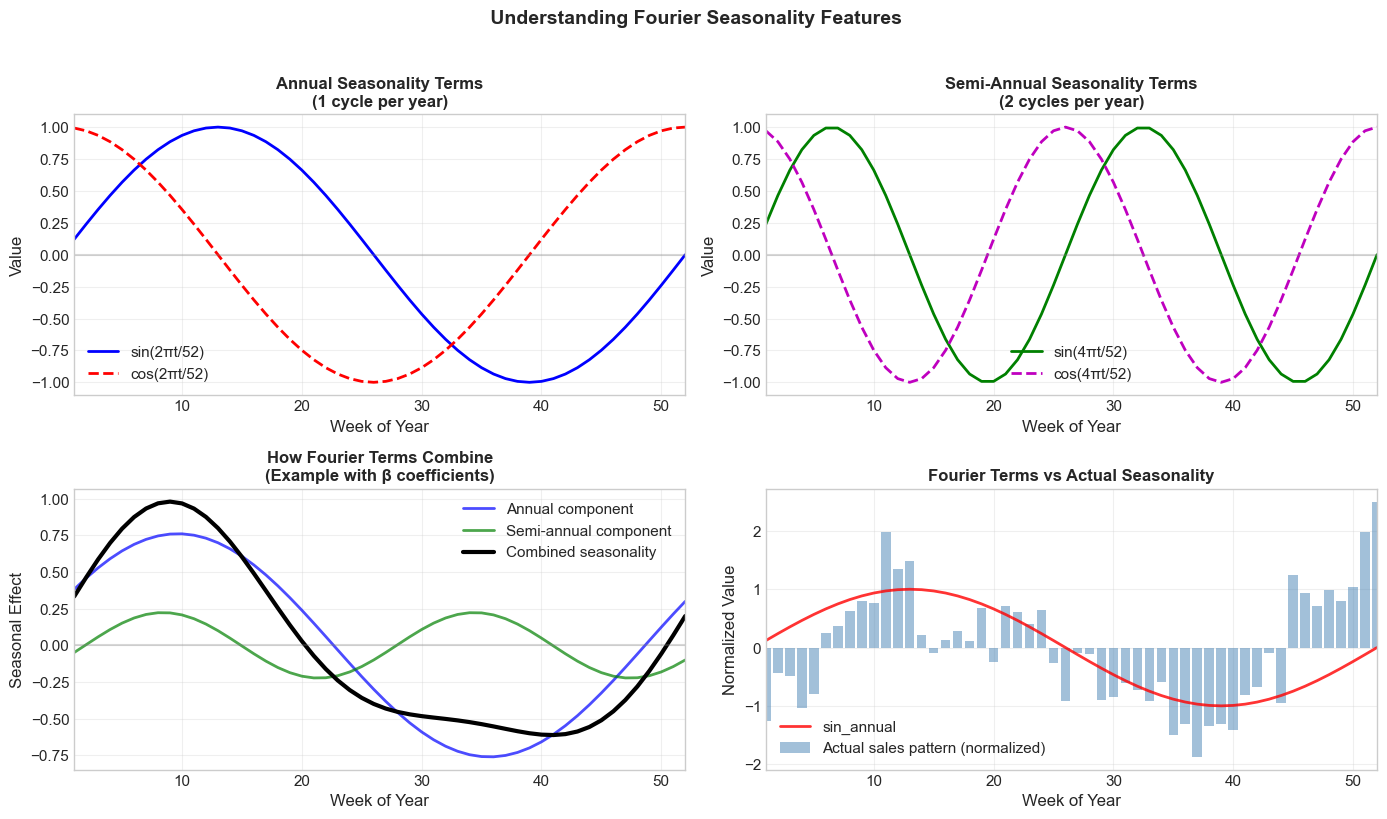


 FOURIER TERMS SUMMARY

  Formula for seasonality at frequency k:

    sin_k = sin(2πk × t / P)    where t = week_of_year, P = 52 weeks
    cos_k = cos(2πk × t / P)    

  In our model:
    k=1: Annual seasonality    → sin_annual, cos_annual  (1 cycle/year)
    k=2: Semi-annual seasonality → sin_semi, cos_semi    (2 cycles/year)

  The regression will learn coefficients β that combine these:
    Seasonal_effect = β₁×sin_annual + β₂×cos_annual + β₃×sin_semi + β₄×cos_semi

  This captures smooth, periodic variations in sales!

 Features created:
   - trend: Linear time trend
   - sin_annual, cos_annual: Annual seasonality (Fourier)
   - sin_semi, cos_semi: Semi-annual seasonality
   - quarter: Quarter of year (1-4)
   - is_holiday_period: Binary holiday indicator

 DATA SPLIT
Training set: 130 weeks (2022-01-03 to 2024-06-24)
Holdout set:  26 weeks (2024-07-01 to 2024-12-23)


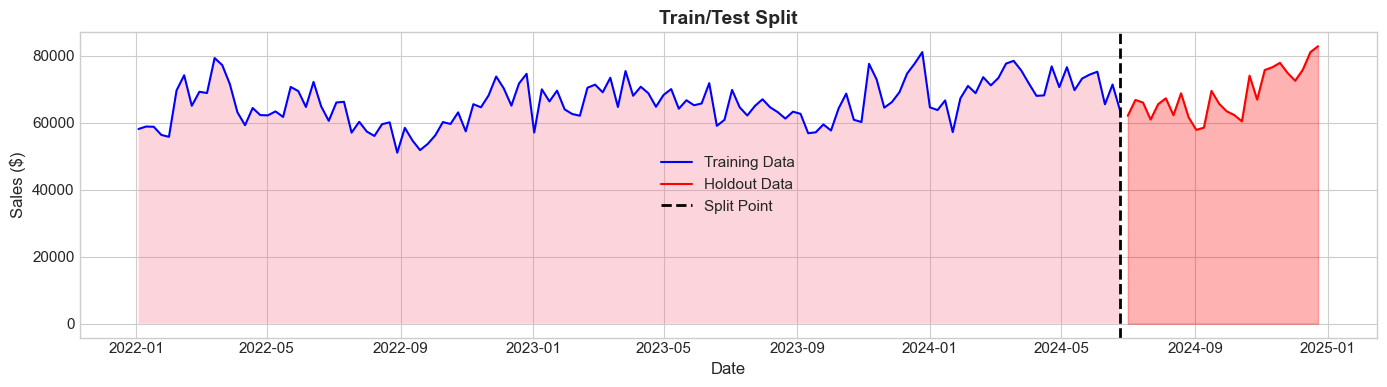

In [9]:
# Data Preprocessing

# 1. Check for missing values
print("=" * 60)
print(" DATA QUALITY CHECK")
print("=" * 60)
print(f"\nMissing values:\n{df.isnull().sum()}")

# 2. Create additional features for modeling

# Trend variable (linear time trend)
df['trend'] = np.arange(len(df))

# ============================================================================
# FOURIER TERMS FOR SEASONALITY
# ============================================================================
# 
# WHY FOURIER TERMS?
# ------------------
# Seasonality in time series (e.g., weekly, monthly, annual patterns) can be
# modeled using Fourier series - a mathematical representation of periodic 
# functions using sine and cosine waves.
#
# KEY ADVANTAGES OVER DUMMY VARIABLES:
# 1. SMOOTH transitions: Dummy variables create abrupt jumps between periods,
#    while Fourier terms create smooth, continuous seasonal curves.
# 2. FEWER parameters: To model 52 weeks with dummies, you'd need 51 parameters.
#    With Fourier terms, just 2-4 parameters can capture annual seasonality.
# 3. FLEXIBLE: Adding more sin/cos pairs captures more complex seasonal shapes.
# 4. INTERPRETABLE: Each pair captures a specific frequency of seasonality.
#
# THE MATH:
# ---------
# For annual seasonality with period P=52 weeks:
#   sin_annual = sin(2π × week / 52)  → completes 1 full cycle per year
#   cos_annual = cos(2π × week / 52)  → 90° phase-shifted from sin
#
# For semi-annual seasonality (2 cycles per year):
#   sin_semi = sin(4π × week / 52)    → completes 2 full cycles per year
#   cos_semi = cos(4π × week / 52)
#
# WHY BOTH SIN AND COS?
# ---------------------
# Using both allows the model to capture seasonality regardless of its phase.
# Together, they can represent ANY shifted sinusoidal pattern:
#   A × sin(x) + B × cos(x) = R × sin(x + φ)
# where R = √(A² + B²) is the amplitude and φ = arctan(B/A) is the phase shift.
# ============================================================================

# Annual seasonality (frequency = 1 cycle per year)
df['sin_annual'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
df['cos_annual'] = np.cos(2 * np.pi * df['week_of_year'] / 52)

# Semi-annual seasonality (frequency = 2 cycles per year)
df['sin_semi'] = np.sin(4 * np.pi * df['week_of_year'] / 52)
df['cos_semi'] = np.cos(4 * np.pi * df['week_of_year'] / 52)

# ============================================================================
# VISUALIZE FOURIER SEASONALITY COMPONENTS
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Get first year of data for cleaner visualization
first_year_mask = df['date'] < df['date'].min() + pd.Timedelta(weeks=52)
plot_df = df[first_year_mask].copy()

# Plot 1: Sin & Cos Annual (top left)
ax1 = axes[0, 0]
ax1.plot(plot_df['week_of_year'], plot_df['sin_annual'], 'b-', linewidth=2, label='sin(2πt/52)')
ax1.plot(plot_df['week_of_year'], plot_df['cos_annual'], 'r--', linewidth=2, label='cos(2πt/52)')
ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax1.set_xlabel('Week of Year')
ax1.set_ylabel('Value')
ax1.set_title('Annual Seasonality Terms\n(1 cycle per year)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.set_xlim(1, 52)
ax1.grid(True, alpha=0.3)

# Plot 2: Sin & Cos Semi-Annual (top right)
ax2 = axes[0, 1]
ax2.plot(plot_df['week_of_year'], plot_df['sin_semi'], 'g-', linewidth=2, label='sin(4πt/52)')
ax2.plot(plot_df['week_of_year'], plot_df['cos_semi'], 'm--', linewidth=2, label='cos(4πt/52)')
ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax2.set_xlabel('Week of Year')
ax2.set_ylabel('Value')
ax2.set_title('Semi-Annual Seasonality Terms\n(2 cycles per year)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.set_xlim(1, 52)
ax2.grid(True, alpha=0.3)

# Plot 3: Combined effect with different weights (bottom left)
ax3 = axes[1, 0]
# Simulate how regression coefficients combine these
weights_annual = [0.7, 0.3]  # Example coefficients for sin/cos annual
weights_semi = [0.2, -0.1]   # Example coefficients for sin/cos semi-annual

combined_annual = weights_annual[0] * plot_df['sin_annual'] + weights_annual[1] * plot_df['cos_annual']
combined_semi = weights_semi[0] * plot_df['sin_semi'] + weights_semi[1] * plot_df['cos_semi']
combined_total = combined_annual + combined_semi

ax3.plot(plot_df['week_of_year'], combined_annual, 'b-', linewidth=2, alpha=0.7, label='Annual component')
ax3.plot(plot_df['week_of_year'], combined_semi, 'g-', linewidth=2, alpha=0.7, label='Semi-annual component')
ax3.plot(plot_df['week_of_year'], combined_total, 'k-', linewidth=3, label='Combined seasonality')
ax3.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax3.set_xlabel('Week of Year')
ax3.set_ylabel('Seasonal Effect')
ax3.set_title('How Fourier Terms Combine\n(Example with β coefficients)', fontsize=12, fontweight='bold')
ax3.legend()
ax3.set_xlim(1, 52)
ax3.grid(True, alpha=0.3)

# Plot 4: Comparison with actual sales pattern (bottom right)
ax4 = axes[1, 1]
# Normalize sales to show seasonal pattern
sales_by_week = df.groupby('week_of_year')['sales'].mean()
sales_normalized = (sales_by_week - sales_by_week.mean()) / sales_by_week.std()
ax4.bar(sales_by_week.index, sales_normalized, alpha=0.5, color='steelblue', label='Actual sales pattern (normalized)')
ax4.plot(plot_df['week_of_year'], plot_df['sin_annual'], 'r-', linewidth=2, alpha=0.8, label='sin_annual')
ax4.set_xlabel('Week of Year')
ax4.set_ylabel('Normalized Value')
ax4.set_title('Fourier Terms vs Actual Seasonality', fontsize=12, fontweight='bold')
ax4.legend()
ax4.set_xlim(1, 52)
ax4.grid(True, alpha=0.3)

plt.suptitle(' Understanding Fourier Seasonality Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print(" FOURIER TERMS SUMMARY")
print("=" * 70)
print("""
  Formula for seasonality at frequency k:
  
    sin_k = sin(2πk × t / P)    where t = week_of_year, P = 52 weeks
    cos_k = cos(2πk × t / P)    
    
  In our model:
    k=1: Annual seasonality    → sin_annual, cos_annual  (1 cycle/year)
    k=2: Semi-annual seasonality → sin_semi, cos_semi    (2 cycles/year)
    
  The regression will learn coefficients β that combine these:
    Seasonal_effect = β₁×sin_annual + β₂×cos_annual + β₃×sin_semi + β₄×cos_semi
    
  This captures smooth, periodic variations in sales!
""")

# Day of week encoding (if we had daily data)
# For weekly data, we can use week-of-month or quarter
df['quarter'] = df['date'].dt.quarter

# 3. Holiday indicator (already in data, but let's create a binary version)
df['is_holiday_period'] = (df['holidays'] != 0).astype(int)

print(" Features created:")
print("   - trend: Linear time trend")
print("   - sin_annual, cos_annual: Annual seasonality (Fourier)")
print("   - sin_semi, cos_semi: Semi-annual seasonality")
print("   - quarter: Quarter of year (1-4)")
print("   - is_holiday_period: Binary holiday indicator")

# 4. Train/Test Split (time-based)
HOLDOUT_WEEKS = 26  # Last 26 weeks for validation (~6 months)

train_df = df.iloc[:-HOLDOUT_WEEKS].copy()
test_df = df.iloc[-HOLDOUT_WEEKS:].copy()

print(f"\n DATA SPLIT")
print("=" * 60)
print(f"Training set: {len(train_df)} weeks ({train_df['date'].min().strftime('%Y-%m-%d')} to {train_df['date'].max().strftime('%Y-%m-%d')})")
print(f"Holdout set:  {len(test_df)} weeks ({test_df['date'].min().strftime('%Y-%m-%d')} to {test_df['date'].max().strftime('%Y-%m-%d')})")

# Visualize the split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df['date'], train_df['sales'], 'b-', label='Training Data', linewidth=1.5)
ax.plot(test_df['date'], test_df['sales'], 'r-', label='Holdout Data', linewidth=1.5)
ax.axvline(x=train_df['date'].max(), color='black', linestyle='--', linewidth=2, label='Split Point')
ax.fill_between(train_df['date'], train_df['sales'], alpha=0.3)
ax.fill_between(test_df['date'], test_df['sales'], alpha=0.3, color='red')
ax.set_xlabel('Date')
ax.set_ylabel('Sales ($)')
ax.set_title('Train/Test Split', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---

# Section 5: Adstock Transformation - Theory and Implementation

## 5.1 What is Adstock?

**Adstock** (short for "advertising stock") captures the **carryover effect** of advertising. When you see an ad today, it doesn't just influence you today—the memory persists and can influence your purchase decision days or weeks later.

### The Intuition:
1. You see a radio commercial for a product
2. You don't buy immediately
3. A week later, you're at the store and remember the ad
4. You make the purchase

The ad "carried over" its effect from week 1 to week 2.

---

## 5.2 Geometric Adstock (Most Common)

The simplest and most widely used adstock model is the **geometric decay** model:

$$\text{Adstock}_t = X_t + \lambda \cdot \text{Adstock}_{t-1}$$

Where:
- $X_t$ = Original spend/impressions at time $t$
- $\lambda$ = **Decay rate** (retention rate), $0 \leq \lambda < 1$
- $\text{Adstock}_t$ = Transformed value at time $t$

### Interpretation of $\lambda$ (Decay Rate):
- $\lambda = 0$: No carryover, effect is immediate and vanishes
- $\lambda = 0.5$: 50% of the effect carries over to the next period
- $\lambda = 0.9$: 90% carries over (very persistent, like brand advertising)

### Half-Life Calculation:
The **half-life** tells us when half the advertising effect has decayed:

$$\text{Half-Life} = \frac{\ln(0.5)}{\ln(\lambda)} = \frac{-0.693}{\ln(\lambda)}$$

| Decay Rate ($\lambda$) | Half-Life (periods) | Typical Channel |
|----------------------|---------------------|-----------------|
| 0.3 | 0.6 | Search, Social (direct response) |
| 0.5 | 1.0 | Digital display |
| 0.7 | 1.9 | Radio |
| 0.8 | 3.1 | Radio/Print |
| 0.9 | 6.6 | Brand campaigns |

---

## 5.3 Alternative Adstock Models

### Delayed Adstock
Sometimes the effect doesn't start immediately (e.g., awareness campaigns):

$$\text{Adstock}_t = \theta \cdot X_{t-\tau} + \lambda \cdot \text{Adstock}_{t-1}$$

Where $\tau$ is the delay in periods.

### Weibull Adstock
More flexible decay shape (can have initial increase before decay):

$$w_l = 1 - \text{CDF}_{\text{Weibull}}(l; \text{shape}, \text{scale})$$

This is used in Meta's Robyn and Google's Meridian.

 GEOMETRIC ADSTOCK DEMONSTRATION


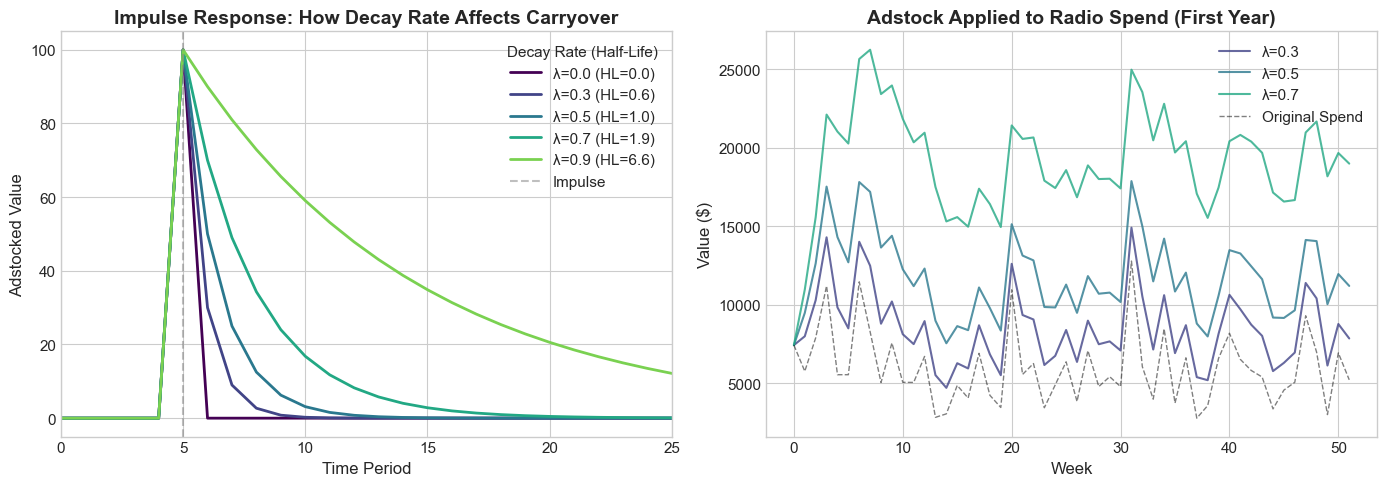


 DECAY RATE TO HALF-LIFE CONVERSION
----------------------------------------
  Decay rate λ = 0.10 → Half-life = 0.30 periods
  Decay rate λ = 0.30 → Half-life = 0.58 periods
  Decay rate λ = 0.50 → Half-life = 1.00 periods
  Decay rate λ = 0.70 → Half-life = 1.94 periods
  Decay rate λ = 0.80 → Half-life = 3.11 periods
  Decay rate λ = 0.90 → Half-life = 6.58 periods
  Decay rate λ = 0.95 → Half-life = 13.51 periods

 WEIBULL ADSTOCK DEMONSTRATION

The Weibull distribution offers MORE FLEXIBILITY than geometric decay:

  Weight(lag) = exp(-(lag/scale)^shape)

SHAPE PARAMETER (k):
  • k < 1: "Front-loaded" - Maximum effect immediately, rapid decay
           Good for: Flash sales, urgent promotions
  • k = 1: Exponential decay (equivalent to geometric adstock)
           Good for: Standard advertising campaigns
  • k > 1: "Delayed peak" - Effect builds up then decays
           Good for: Brand building, awareness campaigns

SCALE PARAMETER (λ):
  • Controls how long the effect lasts
 

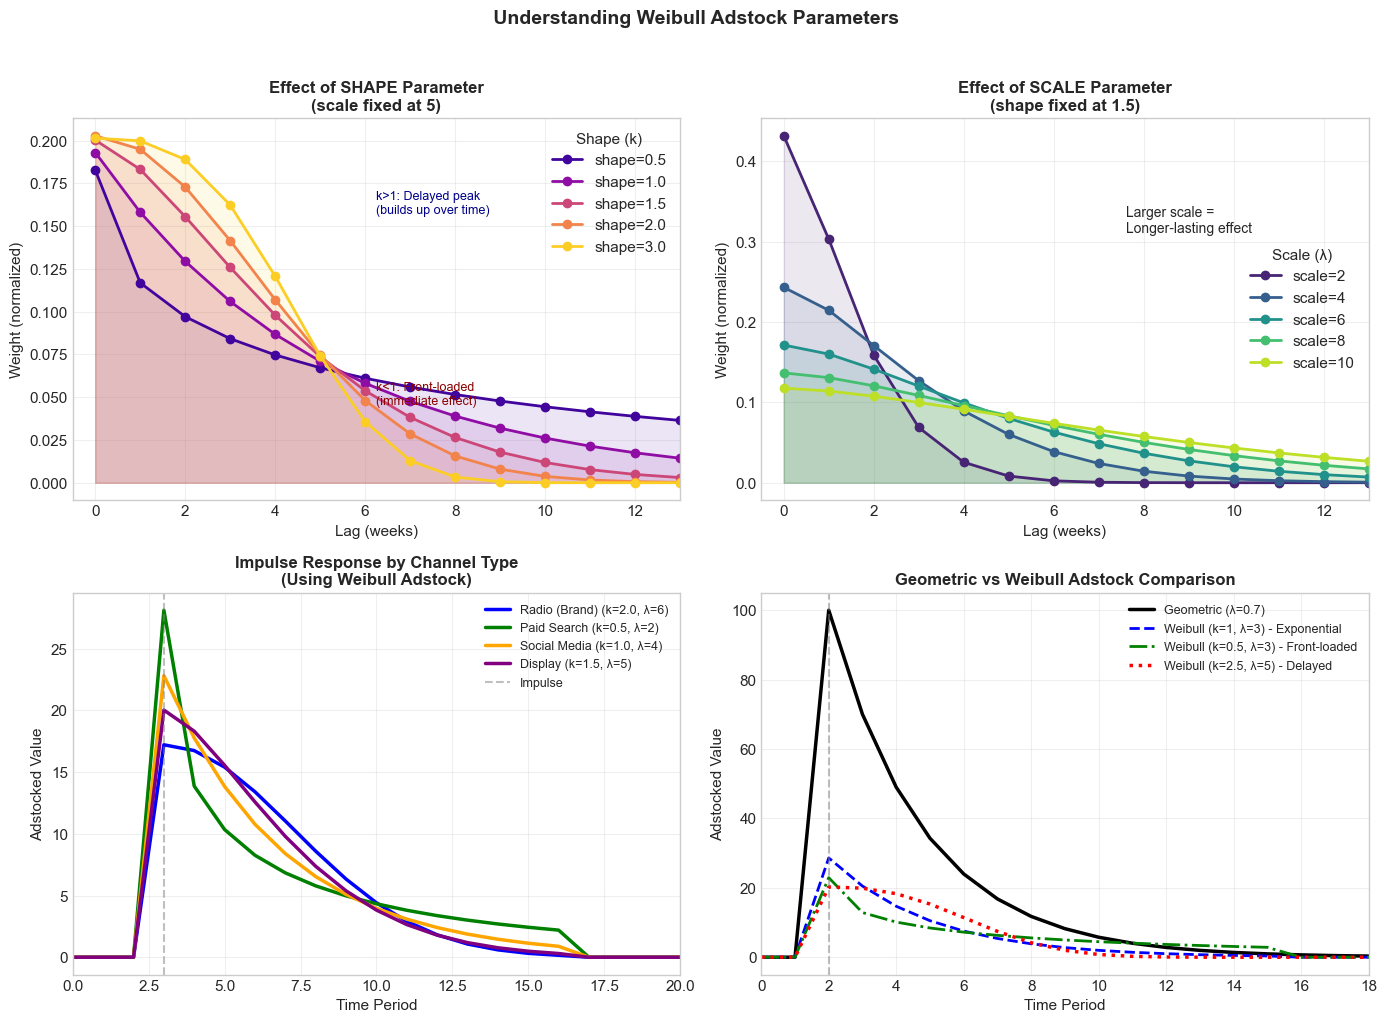


 WEIBULL PARAMETER GUIDELINES BY CHANNEL

Channel Type         Shape (k)    Scale (λ)    Interpretation
----------------------------------------------------------------------
Paid Search          0.3 - 0.8    1 - 3        Immediate, short-lived effect
Social Media         0.8 - 1.2    2 - 5        Quick response, moderate decay
Display Ads          1.0 - 1.5    3 - 6        Balanced immediate + carryover
Radio Advertising    1.5 - 2.5    4 - 8        Builds over time, long-lasting
Brand Campaigns      2.0 - 3.0    6 - 12       Slow build, very persistent
----------------------------------------------------------------------

 KEY INSIGHT: Weibull adstock is preferred over geometric because:
   1. It can model DELAYED effects (shape > 1)
   2. Used by industry tools: Meta's Robyn, Google's Meridian
   3. More realistic for radio/brand where effect builds over exposures



In [10]:
# Implementation of Adstock Transformations

def geometric_adstock(x, decay_rate):
    """
    Apply geometric adstock transformation.
    
    Parameters:
    -----------
    x : array-like
        Input time series (spend, impressions, etc.)
    decay_rate : float
        Decay rate (lambda), between 0 and 1
        
    Returns:
    --------
    array : Adstocked values
    """
    x = np.array(x)
    adstocked = np.zeros_like(x, dtype=float)
    adstocked[0] = x[0]
    
    for t in range(1, len(x)):
        adstocked[t] = x[t] + decay_rate * adstocked[t-1]
    
    return adstocked


def weibull_adstock(x, shape, scale, max_lag=13):
    """
    Apply Weibull adstock transformation (used in Robyn/Meridian).
    
    Parameters:
    -----------
    x : array-like
        Input time series
    shape : float
        Weibull shape parameter (k)
        - k < 1: More weight on immediate effect, rapid initial decay
        - k = 1: Exponential decay (equivalent to geometric)
        - k > 1: Delayed peak effect, slower initial decay
    scale : float
        Weibull scale parameter (lambda)
        - Controls the "spread" of the effect over time
        - Larger scale = longer-lasting effect
    max_lag : int
        Maximum lag to consider
        
    Returns:
    --------
    array : Adstocked values
    """
    x = np.array(x)
    n = len(x)
    
    # Generate Weibull weights
    lags = np.arange(max_lag + 1)
    weights = np.exp(-(lags / scale) ** shape)
    weights = weights / weights.sum()  # Normalize
    
    # Apply convolution (adstock is a convolution with decay kernel)
    adstocked = np.zeros(n)
    for t in range(n):
        for l in range(min(t + 1, max_lag + 1)):
            adstocked[t] += weights[l] * x[t - l]
    
    return adstocked


def calculate_half_life(decay_rate):
    """Calculate the half-life given a decay rate."""
    if decay_rate <= 0 or decay_rate >= 1:
        return float('inf') if decay_rate >= 1 else 0
    return -np.log(2) / np.log(decay_rate)


# Demonstrate adstock with different decay rates
print("=" * 60)
print(" GEOMETRIC ADSTOCK DEMONSTRATION")
print("=" * 60)

# Create a sample impulse (spike of advertising)
n_periods = 30
impulse = np.zeros(n_periods)
impulse[5] = 100  # Single ad spend of $100 in period 5

# Apply different decay rates
decay_rates = [0.0, 0.3, 0.5, 0.7, 0.9]
colors = plt.cm.viridis(np.linspace(0, 0.8, len(decay_rates)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Effect of decay rate on impulse response
for decay, color in zip(decay_rates, colors):
    adstocked = geometric_adstock(impulse, decay)
    half_life = calculate_half_life(decay)
    axes[0].plot(adstocked, label=f'λ={decay:.1f} (HL={half_life:.1f})', 
                 color=color, linewidth=2)

axes[0].axvline(x=5, color='gray', linestyle='--', alpha=0.5, label='Impulse')
axes[0].set_xlabel('Time Period')
axes[0].set_ylabel('Adstocked Value')
axes[0].set_title('Impulse Response: How Decay Rate Affects Carryover', fontsize=14, fontweight='bold')
axes[0].legend(title='Decay Rate (Half-Life)')
axes[0].set_xlim(0, 25)

# Right: Effect on real data (Radio spend)
sample_spend = train_df['radio_spend'].values[:52]  # One year of Radio spend

for decay, color in zip([0.3, 0.5, 0.7], colors[1:4]):
    adstocked = geometric_adstock(sample_spend, decay)
    axes[1].plot(adstocked, label=f'λ={decay:.1f}', color=color, linewidth=1.5, alpha=0.8)

axes[1].plot(sample_spend, 'k--', label='Original Spend', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Value ($)')
axes[1].set_title('Adstock Applied to Radio Spend (First Year)', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print half-lives for reference
print("\n DECAY RATE TO HALF-LIFE CONVERSION")
print("-" * 40)
for decay in [0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95]:
    hl = calculate_half_life(decay)
    print(f"  Decay rate λ = {decay:.2f} → Half-life = {hl:.2f} periods")

# ============================================================================
# WEIBULL ADSTOCK VISUALIZATION
# ============================================================================
print("\n" + "=" * 70)
print(" WEIBULL ADSTOCK DEMONSTRATION")
print("=" * 70)
print("""
The Weibull distribution offers MORE FLEXIBILITY than geometric decay:

  Weight(lag) = exp(-(lag/scale)^shape)

SHAPE PARAMETER (k):
  • k < 1: "Front-loaded" - Maximum effect immediately, rapid decay
           Good for: Flash sales, urgent promotions
  • k = 1: Exponential decay (equivalent to geometric adstock)
           Good for: Standard advertising campaigns
  • k > 1: "Delayed peak" - Effect builds up then decays
           Good for: Brand building, awareness campaigns

SCALE PARAMETER (λ):
  • Controls how long the effect lasts
  • Larger scale = more persistent effect
  • Think of it as "how many periods until significant decay"
""")

# Create a 2x2 visualization for Weibull
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

max_lag = 13
lags = np.arange(max_lag + 1)

# ============================================================================
# Plot 1 (top-left): Varying SHAPE with fixed SCALE
# ============================================================================
ax1 = axes[0, 0]
scale_fixed = 5
shapes = [0.5, 1.0, 1.5, 2.0, 3.0]
colors_shape = plt.cm.plasma(np.linspace(0.1, 0.9, len(shapes)))

for shape, color in zip(shapes, colors_shape):
    weights = np.exp(-(lags / scale_fixed) ** shape)
    weights_norm = weights / weights.sum()
    ax1.plot(lags, weights_norm, 'o-', color=color, linewidth=2, markersize=6,
             label=f'shape={shape:.1f}')
    ax1.fill_between(lags, weights_norm, alpha=0.1, color=color)

ax1.set_xlabel('Lag (weeks)', fontsize=11)
ax1.set_ylabel('Weight (normalized)', fontsize=11)
ax1.set_title(f'Effect of SHAPE Parameter\n(scale fixed at {scale_fixed})', 
              fontsize=12, fontweight='bold')
ax1.legend(title='Shape (k)')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, max_lag)

# Add annotations
ax1.annotate('k<1: Front-loaded\n(immediate effect)', xy=(0.5, 0.25), fontsize=9,
             xycoords='axes fraction', ha='left', color='darkred')
ax1.annotate('k>1: Delayed peak\n(builds up over time)', xy=(0.5, 0.75), fontsize=9,
             xycoords='axes fraction', ha='left', color='darkblue')

# ============================================================================
# Plot 2 (top-right): Varying SCALE with fixed SHAPE
# ============================================================================
ax2 = axes[0, 1]
shape_fixed = 1.5
scales = [2, 4, 6, 8, 10]
colors_scale = plt.cm.viridis(np.linspace(0.1, 0.9, len(scales)))

for scale, color in zip(scales, colors_scale):
    weights = np.exp(-(lags / scale) ** shape_fixed)
    weights_norm = weights / weights.sum()
    ax2.plot(lags, weights_norm, 'o-', color=color, linewidth=2, markersize=6,
             label=f'scale={scale}')
    ax2.fill_between(lags, weights_norm, alpha=0.1, color=color)

ax2.set_xlabel('Lag (weeks)', fontsize=11)
ax2.set_ylabel('Weight (normalized)', fontsize=11)
ax2.set_title(f'Effect of SCALE Parameter\n(shape fixed at {shape_fixed})', 
              fontsize=12, fontweight='bold')
ax2.legend(title='Scale (λ)')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-0.5, max_lag)

ax2.annotate('Larger scale = \nLonger-lasting effect', xy=(0.6, 0.7), fontsize=10,
             xycoords='axes fraction', ha='left')

# ============================================================================
# Plot 3 (bottom-left): Impulse response comparison
# ============================================================================
ax3 = axes[1, 0]

# Different channel archetypes
channel_params = {
    'Radio (Brand)': {'shape': 2.0, 'scale': 6, 'color': 'blue'},
    'Paid Search': {'shape': 0.5, 'scale': 2, 'color': 'green'},
    'Social Media': {'shape': 1.0, 'scale': 4, 'color': 'orange'},
    'Display': {'shape': 1.5, 'scale': 5, 'color': 'purple'},
}

impulse_weibull = np.zeros(25)
impulse_weibull[3] = 100

for name, params in channel_params.items():
    adstocked = weibull_adstock(impulse_weibull, params['shape'], params['scale'], max_lag=13)
    ax3.plot(adstocked, label=f"{name} (k={params['shape']}, λ={params['scale']})", 
             color=params['color'], linewidth=2.5)

ax3.axvline(x=3, color='gray', linestyle='--', alpha=0.5, label='Impulse')
ax3.set_xlabel('Time Period', fontsize=11)
ax3.set_ylabel('Adstocked Value', fontsize=11)
ax3.set_title('Impulse Response by Channel Type\n(Using Weibull Adstock)', 
              fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', fontsize=9)
ax3.set_xlim(0, 20)
ax3.grid(True, alpha=0.3)

# ============================================================================
# Plot 4 (bottom-right): Geometric vs Weibull comparison
# ============================================================================
ax4 = axes[1, 1]

# Compare geometric with equivalent Weibull
impulse_compare = np.zeros(20)
impulse_compare[2] = 100

# Geometric with decay=0.7
geo_adstock = geometric_adstock(impulse_compare, 0.7)

# Weibull with shape=1 (equivalent to exponential)
weib_exp = weibull_adstock(impulse_compare, shape=1.0, scale=3, max_lag=13)

# Weibull with shape<1 (front-loaded)
weib_front = weibull_adstock(impulse_compare, shape=0.5, scale=3, max_lag=13)

# Weibull with shape>1 (delayed peak)
weib_delayed = weibull_adstock(impulse_compare, shape=2.5, scale=5, max_lag=13)

ax4.plot(geo_adstock, 'k-', linewidth=2.5, label='Geometric (λ=0.7)')
ax4.plot(weib_exp, 'b--', linewidth=2, label='Weibull (k=1, λ=3) - Exponential')
ax4.plot(weib_front, 'g-.', linewidth=2, label='Weibull (k=0.5, λ=3) - Front-loaded')
ax4.plot(weib_delayed, 'r:', linewidth=2.5, label='Weibull (k=2.5, λ=5) - Delayed')

ax4.axvline(x=2, color='gray', linestyle='--', alpha=0.5)
ax4.set_xlabel('Time Period', fontsize=11)
ax4.set_ylabel('Adstocked Value', fontsize=11)
ax4.set_title('Geometric vs Weibull Adstock Comparison', fontsize=12, fontweight='bold')
ax4.legend(loc='upper right', fontsize=9)
ax4.set_xlim(0, 18)
ax4.grid(True, alpha=0.3)

plt.suptitle(' Understanding Weibull Adstock Parameters', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "=" * 70)
print(" WEIBULL PARAMETER GUIDELINES BY CHANNEL")
print("=" * 70)
print(f"""
{'Channel Type':<20} {'Shape (k)':<12} {'Scale (λ)':<12} {'Interpretation'}
{'-'*70}
{'Paid Search':<20} {'0.3 - 0.8':<12} {'1 - 3':<12} {'Immediate, short-lived effect'}
{'Social Media':<20} {'0.8 - 1.2':<12} {'2 - 5':<12} {'Quick response, moderate decay'}
{'Display Ads':<20} {'1.0 - 1.5':<12} {'3 - 6':<12} {'Balanced immediate + carryover'}
{'Radio Advertising':<20} {'1.5 - 2.5':<12} {'4 - 8':<12} {'Builds over time, long-lasting'}
{'Brand Campaigns':<20} {'2.0 - 3.0':<12} {'6 - 12':<12} {'Slow build, very persistent'}
{'-'*70}

 KEY INSIGHT: Weibull adstock is preferred over geometric because:
   1. It can model DELAYED effects (shape > 1)
   2. Used by industry tools: Meta's Robyn, Google's Meridian
   3. More realistic for radio/brand where effect builds over exposures
""")

---

# Section 6: Saturation Effects and Diminishing Returns - Hill Function

## 6.1 Why Saturation Matters

In reality, spending more on a marketing channel doesn't produce linear returns forever. There are limits:

1. **Audience Saturation**: You've reached most of your target audience
2. **Frequency Fatigue**: People stop responding after seeing the same ad multiple times
3. **Inventory Constraints**: Premium ad slots are limited
4. **Competitive Dynamics**: More spend = more competition for attention

---

## 6.2 The Hill Function (Sigmoid Saturation)

The **Hill function** (also called Hill equation) is borrowed from pharmacology, where it models drug dose-response:

$$f(x) = \frac{x^{\alpha}}{K^{\alpha} + x^{\alpha}}$$

Where:
- $x$ = Marketing spend/impressions
- $K$ = **Half-saturation point** (EC50) - the spend level where you achieve 50% of maximum effect
- $\alpha$ = **Shape parameter** (Hill coefficient) - controls the steepness

### Interpretation:
- **$K$ (Half-saturation)**: If $K = 50,000$, then at $50k spend, you're at 50% of your maximum potential effect
- **$\alpha$ (Shape)**:
  - $\alpha = 1$: Gentle S-curve (Michaelis-Menten kinetics)
  - $\alpha > 1$: Steeper S-curve (more distinct saturation threshold)
  - $\alpha < 1$: Concave curve (immediate diminishing returns)

---

## 6.3 Alternative Saturation Functions

### 1. Log Transformation (Simple)
$$f(x) = \log(1 + x)$$
- Pros: Simple, widely used
- Cons: No maximum, less interpretable parameters

### 2. Exponential Saturation
$$f(x) = 1 - e^{-\lambda x}$$
- Similar to Hill with $\alpha = 1$

### 3. Power Law
$$f(x) = x^{\gamma}, \quad 0 < \gamma < 1$$
- Also called Box-Cox transformation
- Common in older MMM literature

 SATURATION FUNCTION DEMONSTRATION


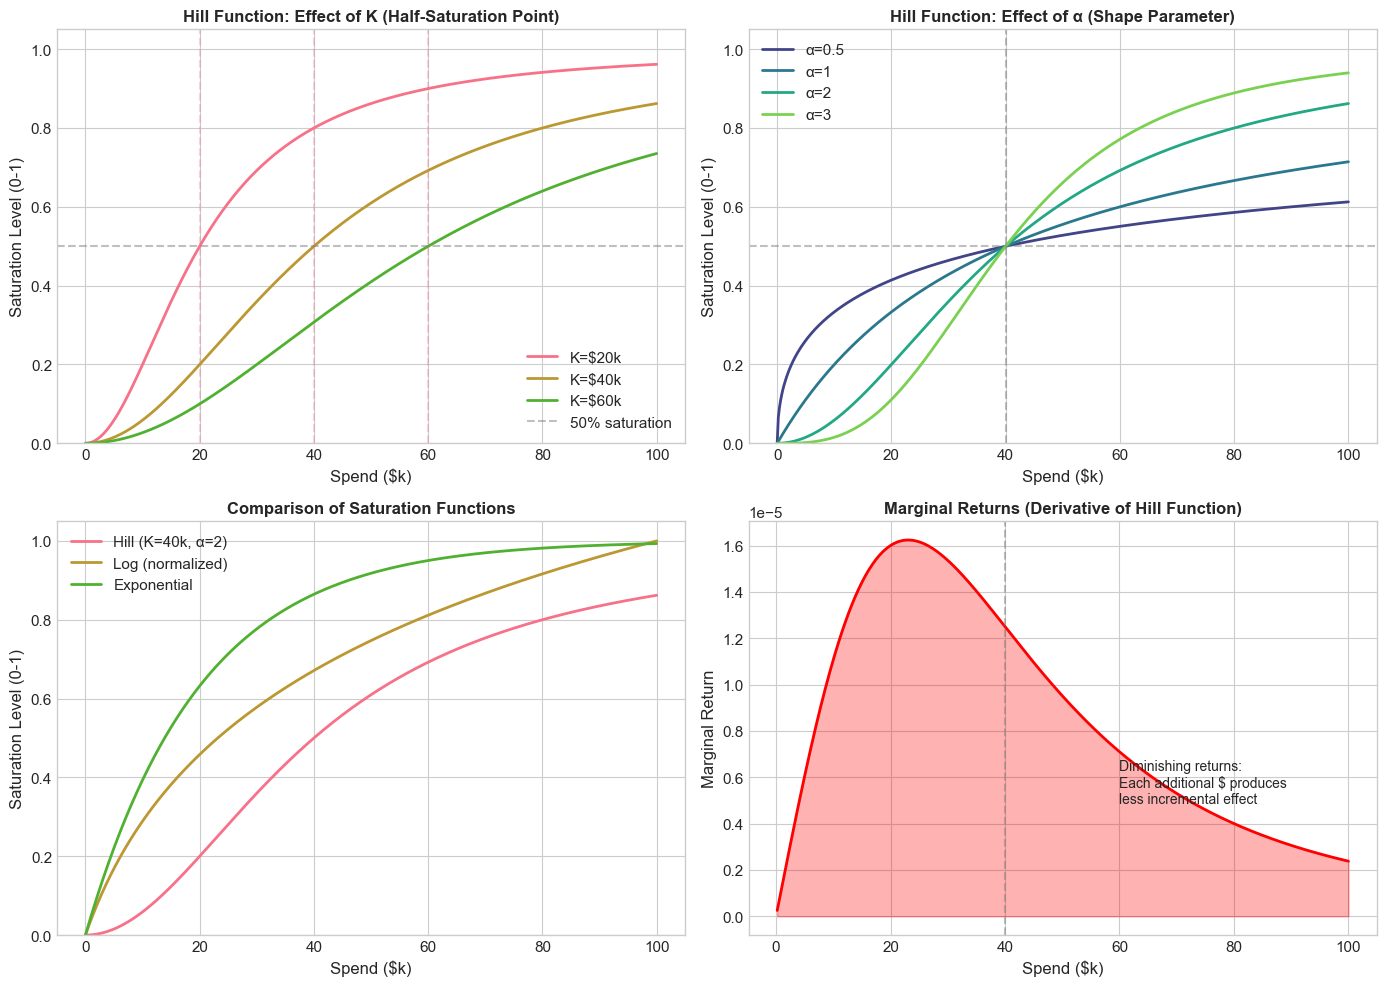


 KEY INSIGHT: Marginal returns decrease as spend increases.
   The optimal budget allocation considers where each channel sits on its saturation curve.


In [11]:
# Implementation of Saturation Functions

def hill_saturation(x, K, alpha):
    """
    Hill function for saturation transformation.
    
    Parameters:
    -----------
    x : array-like
        Input values (spend, impressions)
    K : float
        Half-saturation point (EC50)
    alpha : float
        Shape parameter (Hill coefficient)
        
    Returns:
    --------
    array : Saturated values between 0 and 1
    """
    x = np.array(x)
    return (x ** alpha) / (K ** alpha + x ** alpha)


def log_saturation(x, scale=1):
    """
    Log transformation for saturation.
    
    Parameters:
    -----------
    x : array-like
        Input values
    scale : float
        Scaling factor
        
    Returns:
    --------
    array : Log-transformed values
    """
    x = np.array(x)
    return np.log1p(x / scale)


def exponential_saturation(x, lam):
    """
    Exponential saturation function.
    
    Parameters:
    -----------
    x : array-like
        Input values
    lam : float
        Rate parameter
        
    Returns:
    --------
    array : Saturated values approaching 1
    """
    x = np.array(x)
    return 1 - np.exp(-lam * x)


# Demonstrate saturation functions
print("=" * 60)
print(" SATURATION FUNCTION DEMONSTRATION")
print("=" * 60)

# Generate range of spend values
spend_range = np.linspace(0, 100000, 500)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Hill function with different K values
Ks = [20000, 40000, 60000]
for K in Ks:
    saturated = hill_saturation(spend_range, K=K, alpha=2)
    axes[0, 0].plot(spend_range/1000, saturated, linewidth=2, label=f'K=${K//1000}k')
    axes[0, 0].axvline(x=K/1000, linestyle='--', alpha=0.3)

axes[0, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% saturation')
axes[0, 0].set_xlabel('Spend ($k)')
axes[0, 0].set_ylabel('Saturation Level (0-1)')
axes[0, 0].set_title('Hill Function: Effect of K (Half-Saturation Point)', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].set_ylim(0, 1.05)

# 2. Hill function with different alpha values
alphas = [0.5, 1, 2, 3]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(alphas)))
for alpha, color in zip(alphas, colors):
    saturated = hill_saturation(spend_range, K=40000, alpha=alpha)
    axes[0, 1].plot(spend_range/1000, saturated, linewidth=2, color=color, label=f'α={alpha}')

axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].axvline(x=40, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Spend ($k)')
axes[0, 1].set_ylabel('Saturation Level (0-1)')
axes[0, 1].set_title('Hill Function: Effect of α (Shape Parameter)', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].set_ylim(0, 1.05)

# 3. Compare different saturation functions
saturated_hill = hill_saturation(spend_range, K=40000, alpha=2)
saturated_log = log_saturation(spend_range, scale=10000)
saturated_log = saturated_log / saturated_log.max()  # Normalize
saturated_exp = exponential_saturation(spend_range, lam=0.00005)

axes[1, 0].plot(spend_range/1000, saturated_hill, linewidth=2, label='Hill (K=40k, α=2)')
axes[1, 0].plot(spend_range/1000, saturated_log, linewidth=2, label='Log (normalized)')
axes[1, 0].plot(spend_range/1000, saturated_exp, linewidth=2, label='Exponential')
axes[1, 0].set_xlabel('Spend ($k)')
axes[1, 0].set_ylabel('Saturation Level (0-1)')
axes[1, 0].set_title('Comparison of Saturation Functions', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].set_ylim(0, 1.05)

# 4. Marginal Returns (derivative of saturation)
# For Hill: d/dx [x^α / (K^α + x^α)] = α * K^α * x^(α-1) / (K^α + x^α)^2
def hill_marginal(x, K, alpha):
    return alpha * (K ** alpha) * (x ** (alpha - 1)) / ((K ** alpha + x ** alpha) ** 2)

marginal_returns = hill_marginal(spend_range[1:], K=40000, alpha=2)  # Skip x=0

axes[1, 1].plot(spend_range[1:]/1000, marginal_returns, linewidth=2, color='red')
axes[1, 1].fill_between(spend_range[1:]/1000, marginal_returns, alpha=0.3, color='red')
axes[1, 1].axvline(x=40, color='gray', linestyle='--', alpha=0.5, label='K=$40k')
axes[1, 1].set_xlabel('Spend ($k)')
axes[1, 1].set_ylabel('Marginal Return')
axes[1, 1].set_title('Marginal Returns (Derivative of Hill Function)', fontsize=12, fontweight='bold')
axes[1, 1].annotate('Diminishing returns:\nEach additional $ produces\nless incremental effect', 
                    xy=(60, marginal_returns.max()*0.3), fontsize=10)

plt.tight_layout()
plt.show()

print("\n KEY INSIGHT: Marginal returns decrease as spend increases.")
print("   The optimal budget allocation considers where each channel sits on its saturation curve.")

---

# Section 7: Building a Basic Linear MMM (Frequentist Approach)

Now we'll build our first MMM using **Ordinary Least Squares (OLS) regression**. This is the traditional frequentist approach and provides a good baseline.

## 7.1 Model Specification

Our model equation:

$$\text{Sales}_t = \beta_0 + \beta_{\text{trend}} \cdot t + \sum_{s} \gamma_s \cdot \text{Season}_s + \sum_{c} \beta_c \cdot \text{Hill}(\text{Adstock}(X_{c,t})) + \epsilon_t$$

Where:
- Trend is linear in time
- Seasonality uses Fourier terms
- Media channels are adstock + Hill transformed

## 7.2 Approach

1. Apply adstock transformation to each channel (using fixed decay rates initially)
2. Apply Hill saturation
3. Build OLS regression with control variables
4. Evaluate model fit and interpret coefficients

In [12]:
# Build Basic OLS MMM

class SimpleMMM:
    """
    A simple Marketing Mix Model using OLS regression.
    
    This class implements:
    - Geometric adstock transformation
    - Hill saturation transformation
    - Linear regression for effect estimation
    """
    
    def __init__(self):
        self.model = None
        self.results = None
        self.media_columns = None
        self.control_columns = None
        self.adstock_params = None
        self.saturation_params = None
        self.fitted = False
        
    def transform_media(self, df, media_cols, adstock_params, saturation_params):
        """
        Apply adstock and saturation transformations to media variables.
        
        Parameters:
        -----------
        df : DataFrame
            Input data
        media_cols : list
            Names of media spend columns
        adstock_params : dict
            {column: decay_rate}
        saturation_params : dict
            {column: (K, alpha)}
            
        Returns:
        --------
        DataFrame with transformed media columns
        """
        transformed = df.copy()
        
        for col in media_cols:
            # Apply adstock
            decay = adstock_params.get(col, 0.5)
            adstocked = geometric_adstock(df[col].values, decay)
            
            # Apply saturation
            K, alpha = saturation_params.get(col, (df[col].mean() * 2, 1.5))
            saturated = hill_saturation(adstocked, K, alpha)
            
            # Store transformed column
            transformed[f'{col}_transformed'] = saturated
            
        return transformed
    
    def fit(self, df, target_col, media_cols, control_cols, 
            adstock_params, saturation_params):
        """
        Fit the MMM using OLS regression.
        
        Parameters:
        -----------
        df : DataFrame
            Training data
        target_col : str
            Name of target variable (e.g., 'sales')
        media_cols : list
            Names of media spend columns
        control_cols : list
            Names of control variable columns
        adstock_params : dict
            {column: decay_rate}
        saturation_params : dict
            {column: (K, alpha)}
        """
        self.media_columns = media_cols
        self.control_columns = control_cols
        self.adstock_params = adstock_params
        self.saturation_params = saturation_params
        
        # Transform media variables
        df_transformed = self.transform_media(df, media_cols, adstock_params, saturation_params)
        
        # Build feature matrix
        transformed_media_cols = [f'{col}_transformed' for col in media_cols]
        X = df_transformed[transformed_media_cols + control_cols]
        X = sm.add_constant(X)
        
        # Target variable
        y = df_transformed[target_col]
        
        # Fit OLS
        self.model = sm.OLS(y, X)
        self.results = self.model.fit()
        self.fitted = True
        
        return self.results
    
    def predict(self, df):
        """
        Make predictions on new data.
        """
        if not self.fitted:
            raise ValueError("Model must be fitted first!")
            
        # Transform media
        df_transformed = self.transform_media(
            df, self.media_columns, self.adstock_params, self.saturation_params
        )
        
        # Build feature matrix
        transformed_media_cols = [f'{col}_transformed' for col in self.media_columns]
        X = df_transformed[transformed_media_cols + self.control_columns]
        X = sm.add_constant(X)
        
        return self.results.predict(X)
    
    def get_contributions(self, df):
        """
        Decompose predictions into channel contributions.
        """
        if not self.fitted:
            raise ValueError("Model must be fitted first!")
            
        df_transformed = self.transform_media(
            df, self.media_columns, self.adstock_params, self.saturation_params
        )
        
        contributions = {}
        
        # Baseline (intercept)
        contributions['baseline'] = self.results.params['const']
        
        # Media contributions
        for col in self.media_columns:
            transformed_col = f'{col}_transformed'
            coef = self.results.params[transformed_col]
            contributions[col] = coef * df_transformed[transformed_col].values
            
        # Control contributions
        for col in self.control_columns:
            coef = self.results.params[col]
            contributions[col] = coef * df[col].values
            
        return contributions


# Define transformation parameters (initial guesses based on domain knowledge)
# In practice, these would be optimized

# Adstock decay rates
ADSTOCK_PARAMS = {
    'radio_spend': 0.4,    # Radio decays faster
    'digital_spend': 0.3,  # Digital is more immediate
    'social_spend': 0.5    # Social is in between
}

# Saturation parameters (K, alpha)
SATURATION_PARAMS = {
    'radio_spend': (20000, 2.0),
    'digital_spend': (35000, 1.8),
    'social_spend': (25000, 2.0)
}

# Define columns
MEDIA_COLS = ['radio_spend', 'digital_spend', 'social_spend']
CONTROL_COLS = ['trend', 'sin_annual', 'cos_annual', 'sin_semi', 'cos_semi', 'is_holiday_period']

# Fit the model
print("=" * 70)
print(" FITTING BASIC OLS MARKETING MIX MODEL")
print("=" * 70)

mmm_ols = SimpleMMM()
results = mmm_ols.fit(
    df=train_df,
    target_col='sales',
    media_cols=MEDIA_COLS,
    control_cols=CONTROL_COLS,
    adstock_params=ADSTOCK_PARAMS,
    saturation_params=SATURATION_PARAMS
)

print("\n MODEL SUMMARY")
print("=" * 70)
print(results.summary())

 FITTING BASIC OLS MARKETING MIX MODEL

 MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.648
Model:                            OLS   Adj. R-squared:                  0.622
Method:                 Least Squares   F-statistic:                     24.57
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           2.21e-23
Time:                        15:12:21   Log-Likelihood:                -1256.2
No. Observations:                 130   AIC:                             2532.
Df Residuals:                     120   BIC:                             2561.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

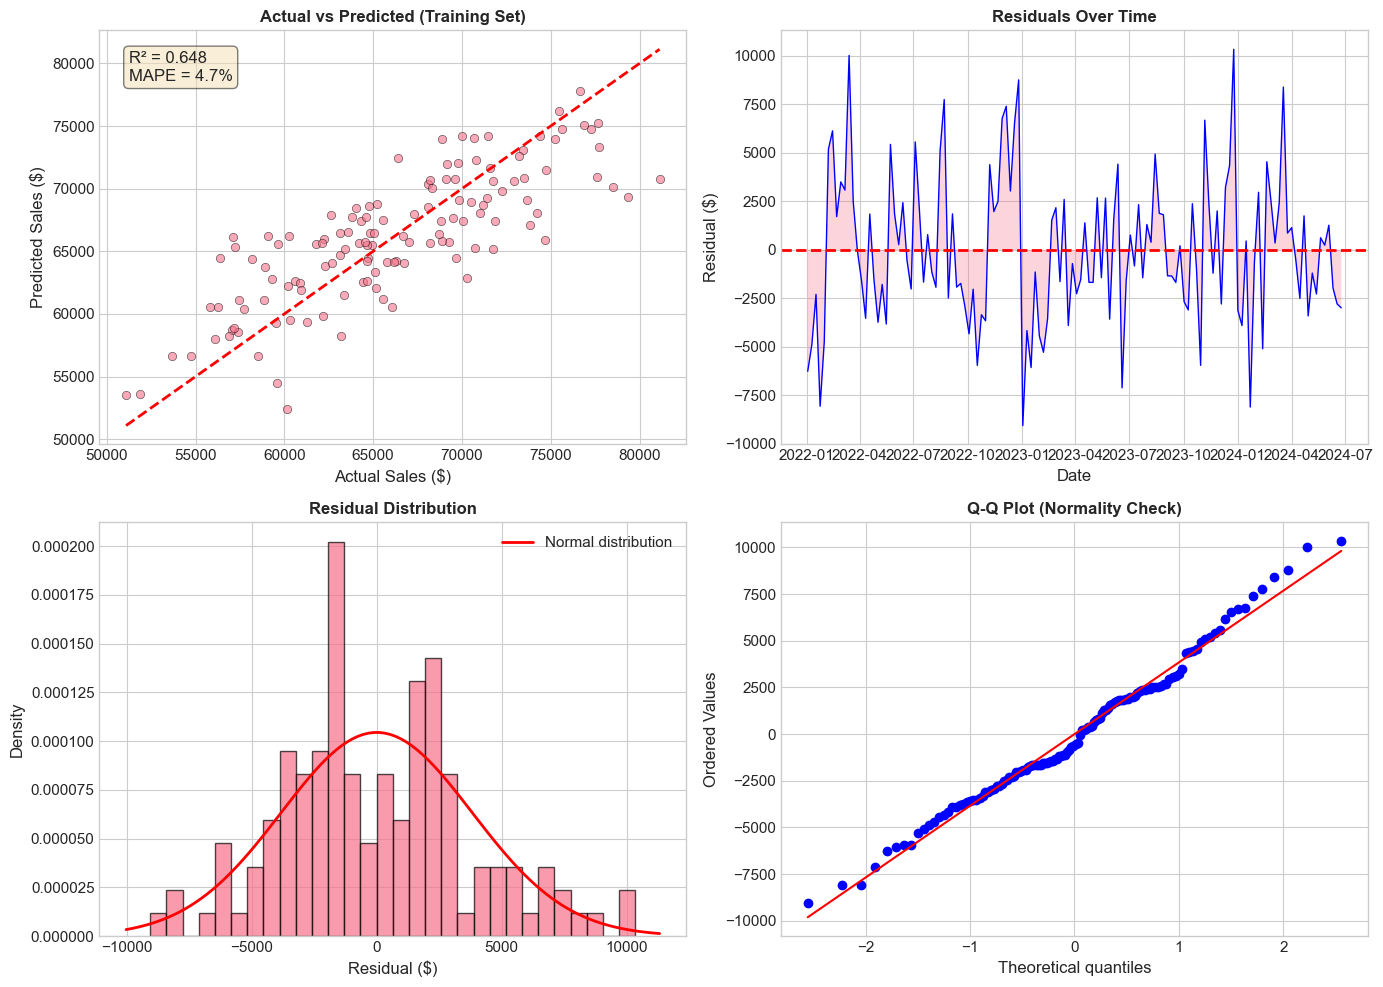


 STATISTICAL DIAGNOSTICS

Durbin-Watson statistic: 1.518
    No significant autocorrelation (1.5 < DW < 2.5)

Shapiro-Wilk test p-value: 0.4814
    Residuals appear normally distributed

R-squared: 0.6482
Adjusted R-squared: 0.6218
MAPE: 4.69%


In [13]:
# Model Diagnostics

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Actual vs Predicted
train_pred = mmm_ols.predict(train_df)
axes[0, 0].scatter(train_df['sales'], train_pred, alpha=0.6, edgecolor='k', linewidth=0.5)
axes[0, 0].plot([train_df['sales'].min(), train_df['sales'].max()], 
                [train_df['sales'].min(), train_df['sales'].max()], 'r--', linewidth=2)
axes[0, 0].set_xlabel('Actual Sales ($)')
axes[0, 0].set_ylabel('Predicted Sales ($)')
axes[0, 0].set_title('Actual vs Predicted (Training Set)', fontsize=12, fontweight='bold')

r2 = r2_score(train_df['sales'], train_pred)
mape = mean_absolute_percentage_error(train_df['sales'], train_pred) * 100
axes[0, 0].annotate(f'R² = {r2:.3f}\nMAPE = {mape:.1f}%', 
                    xy=(0.05, 0.95), xycoords='axes fraction', 
                    fontsize=12, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Residuals over time
residuals = train_df['sales'] - train_pred
axes[0, 1].plot(train_df['date'], residuals, 'b-', linewidth=1)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].fill_between(train_df['date'], residuals, alpha=0.3)
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Residual ($)')
axes[0, 1].set_title('Residuals Over Time', fontsize=12, fontweight='bold')

# 3. Residual distribution
axes[1, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, density=True)
xmin, xmax = axes[1, 0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, residuals.mean(), residuals.std())
axes[1, 0].plot(x, p, 'r-', linewidth=2, label='Normal distribution')
axes[1, 0].set_xlabel('Residual ($)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[1, 0].legend()

# 4. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Statistical diagnostics
print("\n" + "=" * 70)
print(" STATISTICAL DIAGNOSTICS")
print("=" * 70)

# Durbin-Watson test for autocorrelation
dw = durbin_watson(residuals)
print(f"\nDurbin-Watson statistic: {dw:.3f}")
if dw < 1.5:
    print("     Positive autocorrelation detected (DW < 1.5)")
elif dw > 2.5:
    print("     Negative autocorrelation detected (DW > 2.5)")
else:
    print("    No significant autocorrelation (1.5 < DW < 2.5)")

# Normality test
_, shapiro_p = stats.shapiro(residuals[:50])  # Shapiro-Wilk limited to 50 samples
print(f"\nShapiro-Wilk test p-value: {shapiro_p:.4f}")
if shapiro_p < 0.05:
    print("     Residuals may not be normally distributed")
else:
    print("    Residuals appear normally distributed")

# R-squared and Adjusted R-squared
print(f"\nR-squared: {results.rsquared:.4f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
print(f"MAPE: {mape:.2f}%")

In [14]:
# Coefficient Interpretation

print("=" * 70)
print(" COEFFICIENT INTERPRETATION")
print("=" * 70)

# Extract coefficients for media channels
print("\n MEDIA CHANNEL COEFFICIENTS")
print("-" * 50)
for col in MEDIA_COLS:
    transformed_col = f'{col}_transformed'
    coef = results.params[transformed_col]
    se = results.bse[transformed_col]
    pvalue = results.pvalues[transformed_col]
    ci_low, ci_high = results.conf_int().loc[transformed_col]
    
    significance = "***" if pvalue < 0.001 else "**" if pvalue < 0.01 else "*" if pvalue < 0.05 else ""
    
    print(f"\n  {col.replace('_spend', '').upper()}")
    print(f"    Coefficient: {coef:,.0f} {significance}")
    print(f"    Std Error:   {se:,.0f}")
    print(f"    95% CI:      [{ci_low:,.0f}, {ci_high:,.0f}]")
    print(f"    p-value:     {pvalue:.4f}")

print("\n\n CONTROL VARIABLE COEFFICIENTS")
print("-" * 50)
print(f"\n  Intercept (Baseline): ${results.params['const']:,.0f}")
for col in CONTROL_COLS:
    coef = results.params[col]
    pvalue = results.pvalues[col]
    significance = "***" if pvalue < 0.001 else "**" if pvalue < 0.01 else "*" if pvalue < 0.05 else ""
    print(f"  {col:25s}: {coef:>10,.1f} {significance}")

print("\n" + "-" * 50)
print("Significance: *** p<0.001, ** p<0.01, * p<0.05")

# Compare to true parameters
print("\n\n" + "=" * 70)
print(" COMPARISON: ESTIMATED vs TRUE PARAMETERS")
print("=" * 70)
print("\n(Note: Exact recovery is difficult due to correlated data and transformations)")
print("\n  TRUE BETA VALUES:")
for channel in ['radio', 'digital', 'social']:
    print(f"    {channel:10s}: {TRUE_PARAMS[f'{channel}_beta']:,}")

print("\n  ESTIMATED (transformed scale - not directly comparable):")
for col in MEDIA_COLS:
    transformed_col = f'{col}_transformed'
    print(f"    {col.replace('_spend', ''):10s}: {results.params[transformed_col]:,.0f}")

 COEFFICIENT INTERPRETATION

 MEDIA CHANNEL COEFFICIENTS
--------------------------------------------------

  RADIO
    Coefficient: 7,945 
    Std Error:   4,465
    95% CI:      [-896, 16,786]
    p-value:     0.0777

  DIGITAL
    Coefficient: 15,884 ***
    Std Error:   1,995
    95% CI:      [11,934, 19,833]
    p-value:     0.0000

  SOCIAL
    Coefficient: 6,491 **
    Std Error:   2,453
    95% CI:      [1,634, 11,347]
    p-value:     0.0092


 CONTROL VARIABLE COEFFICIENTS
--------------------------------------------------

  Intercept (Baseline): $50,589
  trend                    :       59.5 ***
  sin_annual               :    3,707.2 ***
  cos_annual               :    1,691.9 
  sin_semi                 :   -1,755.5 **
  cos_semi                 :      628.1 
  is_holiday_period        :   -1,459.5 

--------------------------------------------------
Significance: *** p<0.001, ** p<0.01, * p<0.05


 COMPARISON: ESTIMATED vs TRUE PARAMETERS

(Note: Exact recovery is diff

---

# Section 8: Building a Bayesian MMM with PyMC

## 8.1 Why Bayesian MMM?

While OLS provides point estimates, **Bayesian MMM** offers several advantages:

### 1. **Uncertainty Quantification**
- Get full posterior distributions, not just point estimates
- Credible intervals that have proper probabilistic interpretation
- Propagate uncertainty through to ROI and budget optimization

### 2. **Prior Information**
- Incorporate domain knowledge (e.g., "Radio decay should be between 0.3-0.6")
- Regularization through priors prevents overfitting
- Handle small sample sizes better

### 3. **Hierarchical Modeling**
- Pool information across regions/products
- Handle sparse data for some segments

### 4. **Flexible Modeling**
- Non-linear effects, time-varying parameters
- Complex correlation structures

---

## 8.2 Bayesian MMM Architecture

In a Bayesian framework, we specify:

1. **Priors**: Our beliefs about parameters before seeing data
2. **Likelihood**: How data is generated given parameters
3. **Posterior**: Updated beliefs after seeing data

$$P(\theta | D) = \frac{P(D | \theta) \cdot P(\theta)}{P(D)}$$

### Typical Priors for MMM:

| Parameter | Prior | Rationale |
|-----------|-------|-----------|
| Adstock decay ($\lambda$) | Beta(2, 2) | Bounded (0,1), slightly favors middle values |
| Hill K (half-saturation) | LogNormal | Positive, allows wide range |
| Hill α (shape) | LogNormal(0, 0.5) | Positive, usually 0.5-3 |
| Media β (effect) | HalfNormal | Positive (spend increases sales) |
| Baseline | Normal | Can be positive or adjusted from mean |

---

## 8.3 Implementation

We'll build a Bayesian MMM that jointly estimates:
- Adstock decay rates
- Saturation parameters
- Media coefficients
- Baseline and controls

**Note**: For computational efficiency in this tutorial, we'll use a simplified version. Production systems would use PyMC, Stan, or NumPyro.

In [16]:
# Bayesian MMM Implementation using Optimization-Based Inference
# (Full MCMC would require PyMC/NumPyro - this is a practical approximation)

class BayesianMMM:
    """
    A Bayesian-inspired Marketing Mix Model.
    
    This implementation uses Maximum A Posteriori (MAP) estimation with
    regularization through priors, plus uncertainty estimation via the Hessian.
    
    For full Bayesian inference, use PyMC, NumPyro, or Stan.
    """
    
    def __init__(self, n_channels):
        self.n_channels = n_channels
        self.params = None
        self.param_names = None
        self.hessian = None
        self.covariance = None
        self.fitted = False
        
    def _unpack_params(self, theta):
        """Unpack parameter vector into named components."""
        idx = 0
        params = {}
        
        # Adstock decay rates (logit-transformed to ensure 0 < lambda < 1)
        params['decay_logit'] = theta[idx:idx+self.n_channels]
        params['decay'] = expit(params['decay_logit'])  # Sigmoid to bound (0,1)
        idx += self.n_channels
        
        # Saturation K (log-transformed to ensure K > 0)
        params['K_log'] = theta[idx:idx+self.n_channels]
        params['K'] = np.exp(params['K_log'])
        idx += self.n_channels
        
        # Saturation alpha (log-transformed to ensure alpha > 0)
        params['alpha_log'] = theta[idx:idx+self.n_channels]
        params['alpha'] = np.exp(params['alpha_log'])
        idx += self.n_channels
        
        # Media betas (log-transformed to ensure beta > 0)
        params['beta_log'] = theta[idx:idx+self.n_channels]
        params['beta'] = np.exp(params['beta_log'])
        idx += self.n_channels
        
        # Baseline
        params['baseline'] = theta[idx]
        idx += 1
        
        # Control coefficients
        params['gamma'] = theta[idx:]
        
        return params
    
    def _compute_prediction(self, params, media_data, control_data):
        """Compute model prediction given parameters."""
        n = len(media_data)
        prediction = np.full(n, params['baseline'])
        
        for c in range(self.n_channels):
            # Apply adstock
            decay = params['decay'][c]
            adstocked = np.zeros(n)
            adstocked[0] = media_data[0, c]
            for t in range(1, n):
                adstocked[t] = media_data[t, c] + decay * adstocked[t-1]
            
            # Apply saturation
            K = params['K'][c]
            alpha = params['alpha'][c]
            saturated = (adstocked ** alpha) / (K ** alpha + adstocked ** alpha + 1e-10)
            
            # Add to prediction
            prediction += params['beta'][c] * saturated
        
        # Add control effects
        if control_data is not None:
            prediction += control_data @ params['gamma']
        
        return prediction
    
    def _neg_log_posterior(self, theta, media_data, control_data, y):
        """
        Compute negative log posterior (for minimization).
        
        This is: -log(likelihood) - log(prior)
        """
        params = self._unpack_params(theta)
        
        # Prediction
        prediction = self._compute_prediction(params, media_data, control_data)
        
        # Likelihood: Normal distribution
        residuals = y - prediction
        sigma = np.std(residuals) + 1e-6
        log_likelihood = -0.5 * np.sum((residuals / sigma) ** 2) - len(y) * np.log(sigma)
        
        # Priors (regularization)
        log_prior = 0
        
        # Decay prior: Beta(2, 2) - favors values around 0.5
        for d in params['decay']:
            if 0 < d < 1:
                log_prior += stats.beta.logpdf(d, 2, 2)
            else:
                log_prior += -1e10
        
        # K prior: LogNormal with mean around current channel mean
        for k in params['K']:
            log_prior += stats.lognorm.logpdf(k, s=1.0, scale=30000)
        
        # Alpha prior: LogNormal, expecting values around 1-2
        for a in params['alpha']:
            log_prior += stats.lognorm.logpdf(a, s=0.5, scale=1.5)
        
        # Beta prior: HalfNormal (positive effects)
        for b in params['beta']:
            if b > 0:
                log_prior += stats.halfnorm.logpdf(b, scale=10000)
            else:
                log_prior += -1e10
        
        return -(log_likelihood + log_prior)
    
    def fit(self, media_data, control_data, y, n_restarts=3):
        """
        Fit the Bayesian MMM using MAP estimation.
        
        Parameters:
        -----------
        media_data : array (n_obs, n_channels)
            Media spend data
        control_data : array (n_obs, n_controls) or None
            Control variable data
        y : array (n_obs,)
            Target variable
        n_restarts : int
            Number of random restarts for optimization
        """
        n = len(y)
        n_controls = control_data.shape[1] if control_data is not None else 0
        
        # Total number of parameters
        n_params = 4 * self.n_channels + 1 + n_controls
        
        best_result = None
        best_loss = np.inf
        
        for restart in range(n_restarts):
            # Initialize parameters
            theta0 = np.zeros(n_params)
            
            # Decay rates (logit scale, starting around 0.5)
            theta0[:self.n_channels] = np.random.normal(0, 0.5, self.n_channels)
            
            # K values (log scale)
            theta0[self.n_channels:2*self.n_channels] = np.log(
                media_data.mean(axis=0) * (2 + np.random.rand(self.n_channels))
            )
            
            # Alpha values (log scale, around 1.5)
            theta0[2*self.n_channels:3*self.n_channels] = np.log(
                1.5 + np.random.rand(self.n_channels) * 0.5
            )
            
            # Beta values (log scale)
            theta0[3*self.n_channels:4*self.n_channels] = np.log(
                5000 + np.random.rand(self.n_channels) * 10000
            )
            
            # Baseline
            theta0[4*self.n_channels] = y.mean() * 0.5
            
            # Control coefficients
            theta0[4*self.n_channels+1:] = np.random.normal(0, 100, n_controls)
            
            # Optimize
            result = minimize(
                self._neg_log_posterior,
                theta0,
                args=(media_data, control_data, y),
                method='L-BFGS-B',
                options={'maxiter': 1000, 'disp': False}
            )
            
            if result.fun < best_loss:
                best_loss = result.fun
                best_result = result
        
        self.params = self._unpack_params(best_result.x)
        self.raw_params = best_result.x
        self.media_data = media_data
        self.control_data = control_data
        self.y = y
        self.fitted = True
        
        # Estimate uncertainty via Hessian (Laplace approximation)
        try:
            from scipy.optimize import approx_fprime
            eps = 1e-5
            n_params = len(best_result.x)
            hessian = np.zeros((n_params, n_params))
            
            for i in range(n_params):
                def grad_i(theta):
                    grad = approx_fprime(theta, self._neg_log_posterior, 
                                        eps, media_data, control_data, y)
                    return grad[i]
                hessian[i, :] = approx_fprime(best_result.x, grad_i, eps)
            
            self.hessian = hessian
            try:
                self.covariance = np.linalg.inv(hessian)
            except:
                self.covariance = None
        except:
            self.hessian = None
            self.covariance = None
        
        return self
    
    def predict(self, media_data, control_data=None):
        """Make predictions."""
        if not self.fitted:
            raise ValueError("Model must be fitted first!")
        return self._compute_prediction(self.params, media_data, control_data)
    
    def get_param_summary(self):
        """Get summary of fitted parameters with uncertainty."""
        summary = []
        
        param_idx = 0
        
        for i in range(self.n_channels):
            # Decay rate
            decay = self.params['decay'][i]
            std = np.nan
            if self.covariance is not None:
                # Delta method for transformed parameter
                logit_std = np.sqrt(max(0, self.covariance[param_idx, param_idx]))
                std = decay * (1 - decay) * logit_std  # Derivative of sigmoid
            
            summary.append({
                'parameter': f'decay_{i+1}',
                'mean': decay,
                'std': std,
                'ci_low': max(0, decay - 1.96*std) if not np.isnan(std) else np.nan,
                'ci_high': min(1, decay + 1.96*std) if not np.isnan(std) else np.nan
            })
            param_idx += 1
        
        # Continue for other parameters...
        
        return pd.DataFrame(summary)


# Prepare data for Bayesian MMM
media_data = train_df[MEDIA_COLS].values
control_data = train_df[CONTROL_COLS].values
y = train_df['sales'].values

# Fit Bayesian MMM
print("=" * 70)
print(" FITTING BAYESIAN MARKETING MIX MODEL (MAP Estimation)")
print("=" * 70)
print("\nThis uses Maximum A Posteriori estimation with regularizing priors...")

bayesian_mmm = BayesianMMM(n_channels=len(MEDIA_COLS))
bayesian_mmm.fit(media_data, control_data, y, n_restarts=5)

print("\n Model fitted successfully!")

# Display estimated parameters
print("\n" + "=" * 70)
print(" ESTIMATED PARAMETERS")
print("=" * 70)

print("\n ADSTOCK DECAY RATES (λ)")
print("-" * 50)
for i, col in enumerate(MEDIA_COLS):
    true_decay = TRUE_PARAMS[f'{col.replace("_spend", "")}_decay']
    est_decay = bayesian_mmm.params['decay'][i]
    half_life = calculate_half_life(est_decay)
    print(f"  {col:20s}: {est_decay:.3f} (HL={half_life:.1f} weeks) | True: {true_decay:.1f}")

print("\n SATURATION PARAMETERS")
print("-" * 50)
for i, col in enumerate(MEDIA_COLS):
    K = bayesian_mmm.params['K'][i]
    alpha = bayesian_mmm.params['alpha'][i]
    true_K = TRUE_PARAMS[f'{col.replace("_spend", "")}_K']
    true_alpha = TRUE_PARAMS[f'{col.replace("_spend", "")}_alpha']
    print(f"  {col:20s}: K=${K:,.0f}, α={alpha:.2f} | True: K=${true_K:,}, α={true_alpha}")

print("\n MEDIA EFFECT SIZES (β)")
print("-" * 50)
for i, col in enumerate(MEDIA_COLS):
    beta = bayesian_mmm.params['beta'][i]
    true_beta = TRUE_PARAMS[f'{col.replace("_spend", "")}_beta']
    print(f"  {col:20s}: ${beta:,.0f} | True: ${true_beta:,}")

print(f"\n BASELINE: ${bayesian_mmm.params['baseline']:,.0f} | True: ${TRUE_PARAMS['baseline']:,}")

 FITTING BAYESIAN MARKETING MIX MODEL (MAP Estimation)

This uses Maximum A Posteriori estimation with regularizing priors...

 Model fitted successfully!

 ESTIMATED PARAMETERS

 ADSTOCK DECAY RATES (λ)
--------------------------------------------------
  radio_spend         : 0.748 (HL=2.4 weeks) | True: 0.4
  digital_spend       : 0.279 (HL=0.5 weeks) | True: 0.3
  social_spend        : 0.496 (HL=1.0 weeks) | True: 0.5

 SATURATION PARAMETERS
--------------------------------------------------
  radio_spend         : K=$12,937, α=1.69 | True: K=$15,000, α=2.0
  digital_spend       : K=$30,113, α=1.95 | True: K=$30,000, α=1.8
  social_spend        : K=$9,858, α=1.29 | True: K=$20,000, α=2.2

 MEDIA EFFECT SIZES (β)
--------------------------------------------------
  radio_spend         : $17,594 | True: $8,000
  digital_spend       : $14,498 | True: $12,000
  social_spend        : $12,560 | True: $6,000

 BASELINE: $33,107 | True: $50,000


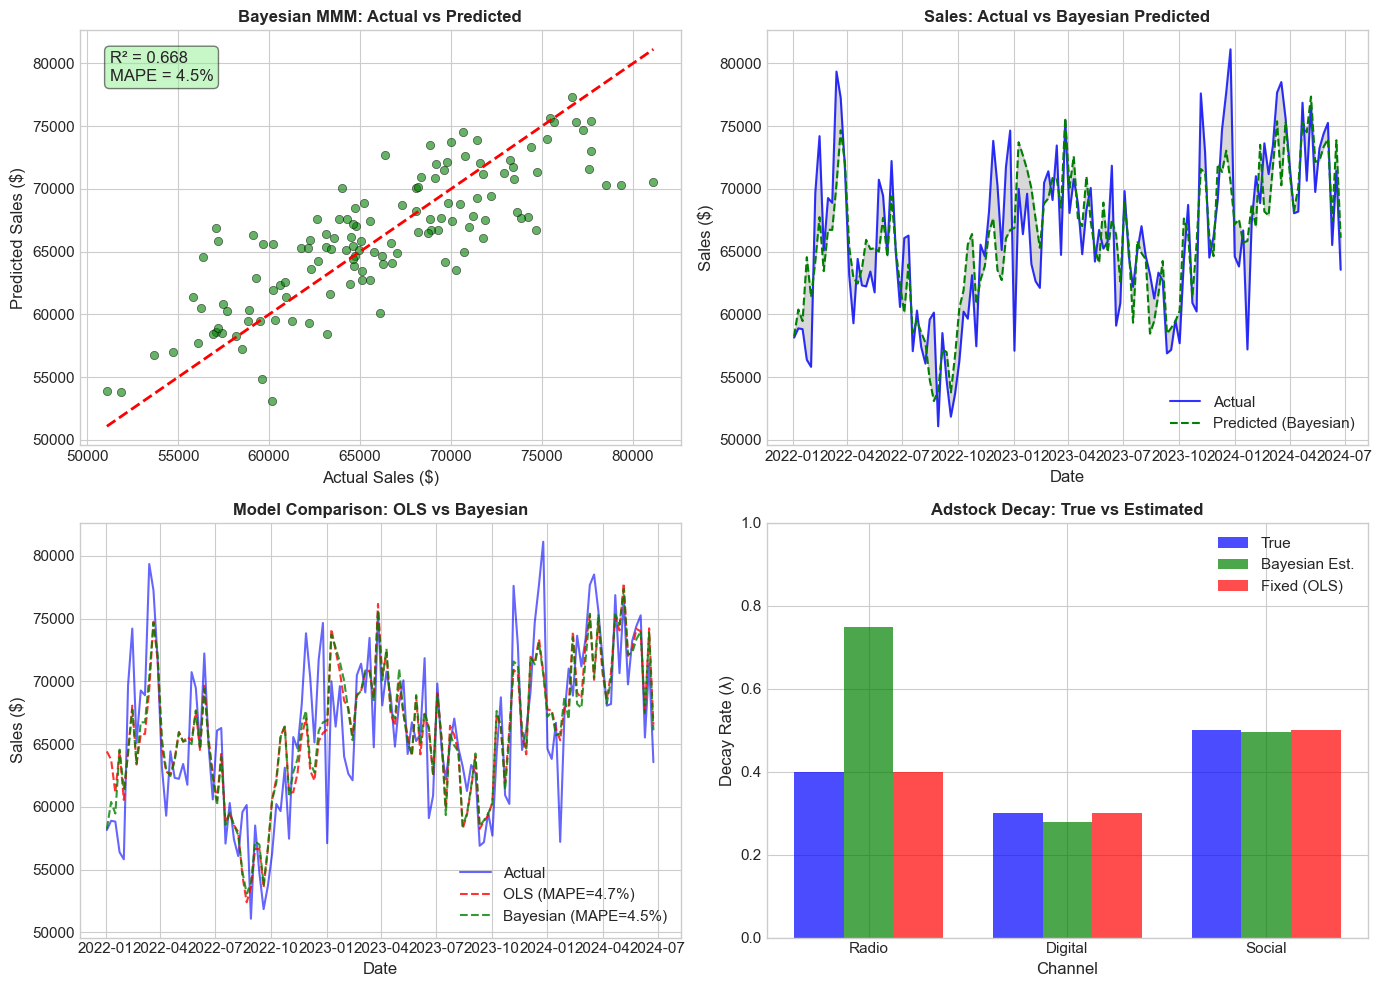


 MODEL COMPARISON SUMMARY

Metric                                OLS        Bayesian
-------------------------------------------------------
R-squared                 0.6482           0.6678
MAPE                      4.69%          4.49%
RMSE                      $3,804      $3,697


In [17]:
# Visualize Bayesian MMM Results

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Actual vs Predicted
bayesian_pred = bayesian_mmm.predict(media_data, control_data)
axes[0, 0].scatter(y, bayesian_pred, alpha=0.6, edgecolor='k', linewidth=0.5, c='green')
axes[0, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
axes[0, 0].set_xlabel('Actual Sales ($)')
axes[0, 0].set_ylabel('Predicted Sales ($)')
axes[0, 0].set_title('Bayesian MMM: Actual vs Predicted', fontsize=12, fontweight='bold')

r2_bayes = r2_score(y, bayesian_pred)
mape_bayes = mean_absolute_percentage_error(y, bayesian_pred) * 100
axes[0, 0].annotate(f'R² = {r2_bayes:.3f}\nMAPE = {mape_bayes:.1f}%', 
                    xy=(0.05, 0.95), xycoords='axes fraction', 
                    fontsize=12, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# 2. Predicted vs Actual Over Time
axes[0, 1].plot(train_df['date'], y, 'b-', label='Actual', linewidth=1.5, alpha=0.8)
axes[0, 1].plot(train_df['date'], bayesian_pred, 'g--', label='Predicted (Bayesian)', linewidth=1.5)
axes[0, 1].fill_between(train_df['date'], y, bayesian_pred, alpha=0.3, color='gray')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Sales ($)')
axes[0, 1].set_title('Sales: Actual vs Bayesian Predicted', fontsize=12, fontweight='bold')
axes[0, 1].legend()

# 3. Compare OLS vs Bayesian predictions
ols_pred = mmm_ols.predict(train_df)
axes[1, 0].plot(train_df['date'], y, 'b-', label='Actual', linewidth=1.5, alpha=0.6)
axes[1, 0].plot(train_df['date'], ols_pred, 'r--', label=f'OLS (MAPE={mape:.1f}%)', linewidth=1.5, alpha=0.8)
axes[1, 0].plot(train_df['date'], bayesian_pred, 'g--', label=f'Bayesian (MAPE={mape_bayes:.1f}%)', linewidth=1.5, alpha=0.8)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Sales ($)')
axes[1, 0].set_title('Model Comparison: OLS vs Bayesian', fontsize=12, fontweight='bold')
axes[1, 0].legend()

# 4. Parameter comparison bar chart
param_comparison = pd.DataFrame({
    'Channel': [col.replace('_spend', '').title() for col in MEDIA_COLS],
    'True Decay': [TRUE_PARAMS[f'{col.replace("_spend", "")}_decay'] for col in MEDIA_COLS],
    'Estimated Decay': bayesian_mmm.params['decay'],
    'Fixed (OLS)': [ADSTOCK_PARAMS[col] for col in MEDIA_COLS]
})

x = np.arange(len(MEDIA_COLS))
width = 0.25
axes[1, 1].bar(x - width, param_comparison['True Decay'], width, label='True', color='blue', alpha=0.7)
axes[1, 1].bar(x, param_comparison['Estimated Decay'], width, label='Bayesian Est.', color='green', alpha=0.7)
axes[1, 1].bar(x + width, param_comparison['Fixed (OLS)'], width, label='Fixed (OLS)', color='red', alpha=0.7)
axes[1, 1].set_xlabel('Channel')
axes[1, 1].set_ylabel('Decay Rate (λ)')
axes[1, 1].set_title('Adstock Decay: True vs Estimated', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(param_comparison['Channel'])
axes[1, 1].legend()
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Model comparison summary
print("\n" + "=" * 70)
print(" MODEL COMPARISON SUMMARY")
print("=" * 70)
print(f"\n{'Metric':<25} {'OLS':>15} {'Bayesian':>15}")
print("-" * 55)
print(f"{'R-squared':<25} {r2:.4f}{'':<10} {r2_bayes:.4f}")
print(f"{'MAPE':<25} {mape:.2f}%{'':<9} {mape_bayes:.2f}%")
print(f"{'RMSE':<25} ${np.sqrt(mean_squared_error(y, ols_pred)):,.0f}{'':<5} ${np.sqrt(mean_squared_error(y, bayesian_pred)):,.0f}")

---

# Section 9: Model Diagnostics and Validation

## 9.1 Why Validation Matters

A good in-sample fit doesn't guarantee a useful model. We need to validate:

1. **Out-of-Sample Prediction**: Can the model predict unseen data?
2. **Time Series Cross-Validation**: Performance across different time periods
3. **Residual Analysis**: Are assumptions met?
4. **Lift Test Calibration**: Do channel effects match experimental results?

---

## 9.2 Key Validation Metrics

| Metric | Formula | Good Range |
|--------|---------|------------|
| **MAPE** | $\frac{1}{n}\sum\frac{|y - \hat{y}|}{y}$ | < 10-15% |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | > 0.85 |
| **NRMSE** | $\frac{RMSE}{\bar{y}}$ | < 15% |
| **Bias** | $\frac{1}{n}\sum(y - \hat{y})$ | Near 0 |

 MODEL VALIDATION

 1. OUT-OF-SAMPLE PREDICTION (Holdout Set)
--------------------------------------------------

   Model  MAPE (%)    RMSE ($)  NRMSE (%)       R²     Bias ($)
     OLS  6.250164 4998.879958    7.30875 0.488185 -1845.542545
Bayesian  8.158183 6698.180528    9.79326 0.081072 -3563.028570


 2. TIME SERIES CROSS-VALIDATION
--------------------------------------------------

Cross-Validation Results (MAPE %):
 fold  ols_mape  bayes_mape
    2 32.580912    5.876227
    3  4.701709    7.737172
    4  3.801148    7.049175
    5  6.250164    8.403343

Mean CV MAPE - OLS: 11.83%
Mean CV MAPE - Bayesian: 7.27%


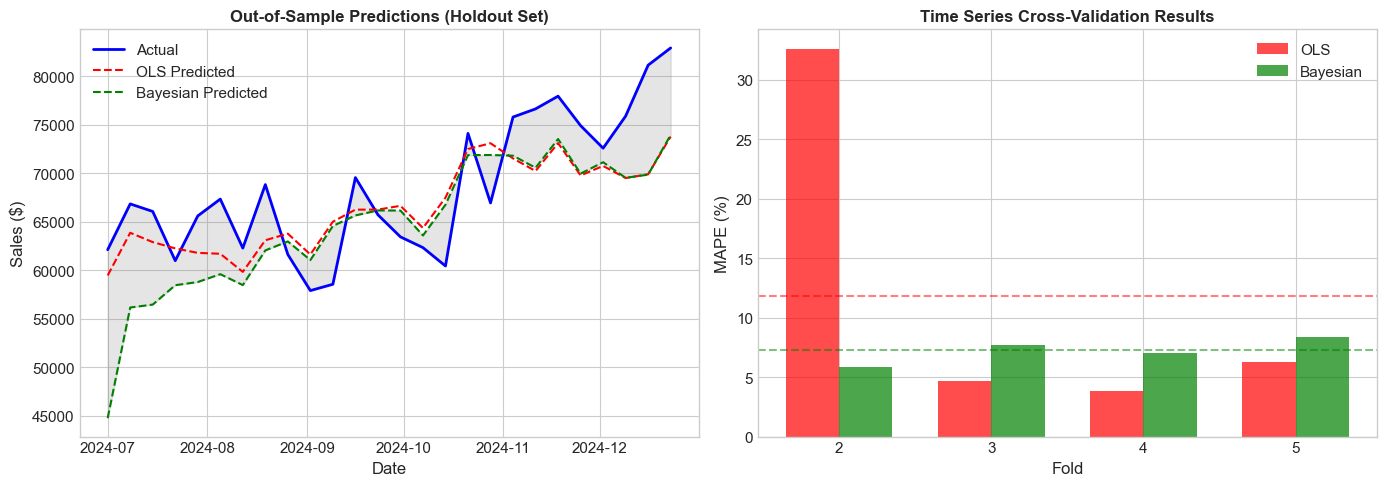

In [18]:
# Comprehensive Model Validation

print("=" * 70)
print(" MODEL VALIDATION")
print("=" * 70)

# 1. Out-of-Sample Prediction (Holdout Set)
print("\n 1. OUT-OF-SAMPLE PREDICTION (Holdout Set)")
print("-" * 50)

# OLS predictions on test set
test_pred_ols = mmm_ols.predict(test_df)

# Bayesian predictions on test set
test_media_data = test_df[MEDIA_COLS].values
test_control_data = test_df[CONTROL_COLS].values
test_pred_bayes = bayesian_mmm.predict(test_media_data, test_control_data)

# Calculate metrics
test_y = test_df['sales'].values

def calculate_metrics(y_true, y_pred, name=""):
    """Calculate comprehensive regression metrics."""
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    nrmse = rmse / y_true.mean() * 100
    r2 = r2_score(y_true, y_pred)
    bias = (y_pred - y_true).mean()
    
    return {
        'Model': name,
        'MAPE (%)': mape,
        'RMSE ($)': rmse,
        'NRMSE (%)': nrmse,
        'R²': r2,
        'Bias ($)': bias
    }

ols_metrics = calculate_metrics(test_y, test_pred_ols, "OLS")
bayes_metrics = calculate_metrics(test_y, test_pred_bayes, "Bayesian")

metrics_df = pd.DataFrame([ols_metrics, bayes_metrics])
print("\n" + metrics_df.to_string(index=False))

# 2. Time Series Cross-Validation
print("\n\n 2. TIME SERIES CROSS-VALIDATION")
print("-" * 50)

tscv = TimeSeriesSplit(n_splits=5)
cv_results = {'fold': [], 'ols_mape': [], 'bayes_mape': []}

for fold, (train_idx, val_idx) in enumerate(tscv.split(df)):
    if len(train_idx) < 30:  # Skip if training set too small
        continue
        
    cv_train = df.iloc[train_idx]
    cv_val = df.iloc[val_idx]
    
    # OLS
    cv_mmm_ols = SimpleMMM()
    cv_mmm_ols.fit(cv_train, 'sales', MEDIA_COLS, CONTROL_COLS, 
                   ADSTOCK_PARAMS, SATURATION_PARAMS)
    cv_pred_ols = cv_mmm_ols.predict(cv_val)
    
    # Bayesian
    cv_media_train = cv_train[MEDIA_COLS].values
    cv_control_train = cv_train[CONTROL_COLS].values
    cv_y_train = cv_train['sales'].values
    
    cv_bayes = BayesianMMM(n_channels=len(MEDIA_COLS))
    cv_bayes.fit(cv_media_train, cv_control_train, cv_y_train, n_restarts=2)
    
    cv_media_val = cv_val[MEDIA_COLS].values
    cv_control_val = cv_val[CONTROL_COLS].values
    cv_pred_bayes = cv_bayes.predict(cv_media_val, cv_control_val)
    
    cv_y_val = cv_val['sales'].values
    
    cv_results['fold'].append(fold + 1)
    cv_results['ols_mape'].append(mean_absolute_percentage_error(cv_y_val, cv_pred_ols) * 100)
    cv_results['bayes_mape'].append(mean_absolute_percentage_error(cv_y_val, cv_pred_bayes) * 100)

cv_df = pd.DataFrame(cv_results)
print("\nCross-Validation Results (MAPE %):")
print(cv_df.to_string(index=False))
print(f"\nMean CV MAPE - OLS: {cv_df['ols_mape'].mean():.2f}%")
print(f"Mean CV MAPE - Bayesian: {cv_df['bayes_mape'].mean():.2f}%")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Holdout predictions
axes[0].plot(test_df['date'], test_y, 'b-', label='Actual', linewidth=2)
axes[0].plot(test_df['date'], test_pred_ols, 'r--', label='OLS Predicted', linewidth=1.5)
axes[0].plot(test_df['date'], test_pred_bayes, 'g--', label='Bayesian Predicted', linewidth=1.5)
axes[0].fill_between(test_df['date'], test_y, test_pred_bayes, alpha=0.2, color='gray')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales ($)')
axes[0].set_title('Out-of-Sample Predictions (Holdout Set)', fontsize=12, fontweight='bold')
axes[0].legend()

# CV Results
x = np.arange(len(cv_df))
width = 0.35
axes[1].bar(x - width/2, cv_df['ols_mape'], width, label='OLS', color='red', alpha=0.7)
axes[1].bar(x + width/2, cv_df['bayes_mape'], width, label='Bayesian', color='green', alpha=0.7)
axes[1].axhline(y=cv_df['ols_mape'].mean(), color='red', linestyle='--', alpha=0.5)
axes[1].axhline(y=cv_df['bayes_mape'].mean(), color='green', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('MAPE (%)')
axes[1].set_title('Time Series Cross-Validation Results', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cv_df['fold'])
axes[1].legend()

plt.tight_layout()
plt.show()

---

# Section 10: Contribution Analysis and Channel Attribution

## 10.1 What is Contribution Analysis?

Contribution analysis **decomposes total sales** into components attributable to:
- **Baseline**: Organic/unattributed sales
- **Each marketing channel**: Sales driven by that channel
- **Control factors**: Seasonality, trend, holidays

This answers: *"What portion of my sales came from each channel?"*

---

## 10.2 Key Metrics

### 1. **Absolute Contribution**
Total sales (in $) driven by a channel over a period:
$$\text{Contribution}_c = \sum_t \beta_c \cdot f(X_{c,t})$$

### 2. **Contribution Share**
Percentage of incremental sales from each channel:
$$\text{Share}_c = \frac{\text{Contribution}_c}{\sum_c \text{Contribution}_c}$$

### 3. **Return on Investment (ROI)**
Revenue generated per dollar spent:
$$\text{ROI}_c = \frac{\text{Contribution}_c}{\text{Spend}_c}$$

### 4. **Marginal ROI (mROI)**
ROI of the last dollar spent (derivative of response curve):
$$\text{mROI}_c = \frac{\partial \text{Response}}{\partial \text{Spend}_c}$$

 CONTRIBUTION ANALYSIS

 TOTAL CONTRIBUTIONS (Training Period)
------------------------------------------------------------
Component               Contribution      Share
------------------------------------------------------------
Baseline             $     4,303,962      50.1%
Radio                $     1,692,577      19.7%
Digital              $       882,303      10.3%
Social               $     1,218,606      14.2%
Controls             $       497,153       5.8%
------------------------------------------------------------
Total Predicted      $     8,594,601
Actual Sales         $     8,596,185


 RETURN ON INVESTMENT (ROI)
------------------------------------------------------------
Channel                   Spend    Contribution        ROI
------------------------------------------------------------
Radio           $       827,162 $     1,692,577      2.05x
Digital         $     3,007,857 $       882,303      0.29x
Social          $     1,648,762 $     1,218,606      0.74x


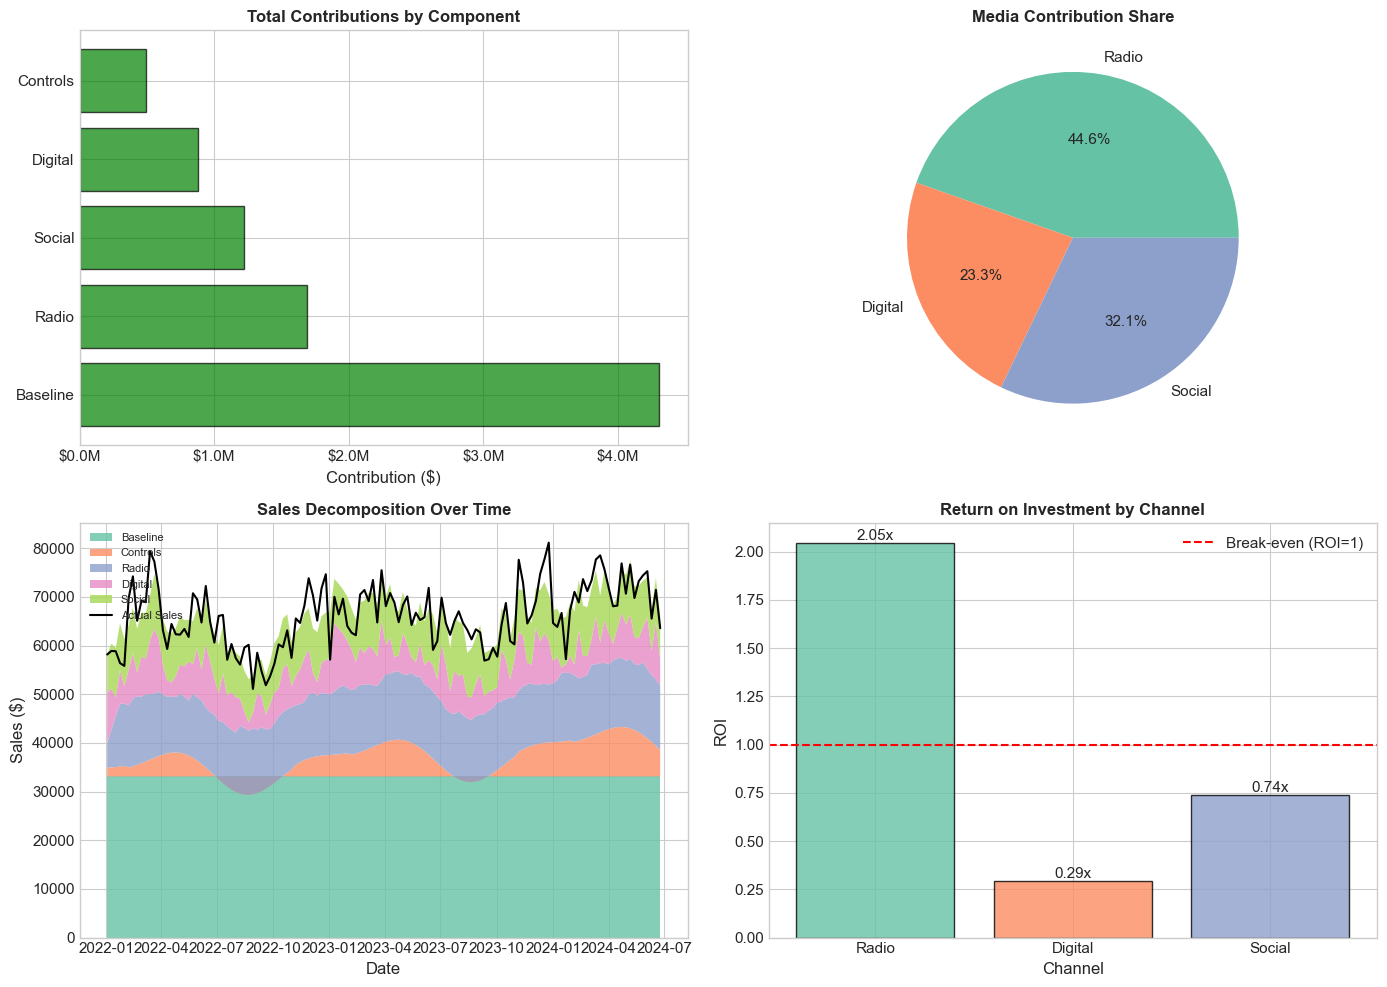

In [19]:
# Contribution Analysis

def compute_contributions(mmm, df, media_cols, control_cols, use_bayesian=False):
    """
    Compute channel contributions from fitted MMM.
    
    Returns:
    --------
    dict: Contributions by component over time
    """
    n = len(df)
    contributions = {}
    
    if use_bayesian:
        # For Bayesian model
        params = mmm.params
        
        # Baseline
        contributions['Baseline'] = np.full(n, params['baseline'])
        
        # Media contributions
        media_data = df[media_cols].values
        for i, col in enumerate(media_cols):
            # Apply transformations
            decay = params['decay'][i]
            adstocked = geometric_adstock(media_data[:, i], decay)
            
            K = params['K'][i]
            alpha = params['alpha'][i]
            saturated = hill_saturation(adstocked, K, alpha)
            
            contributions[col.replace('_spend', '').title()] = params['beta'][i] * saturated
        
        # Control contributions
        control_data = df[control_cols].values
        control_contribution = control_data @ params['gamma']
        contributions['Controls'] = control_contribution
        
    else:
        # For OLS model
        results = mmm.results
        
        # Get transformed data
        df_transformed = mmm.transform_media(df, media_cols, mmm.adstock_params, mmm.saturation_params)
        
        # Baseline
        contributions['Baseline'] = np.full(n, results.params['const'])
        
        # Media contributions
        for col in media_cols:
            transformed_col = f'{col}_transformed'
            contributions[col.replace('_spend', '').title()] = (
                results.params[transformed_col] * df_transformed[transformed_col].values
            )
        
        # Control contributions
        control_contrib = np.zeros(n)
        for col in control_cols:
            control_contrib += results.params[col] * df[col].values
        contributions['Controls'] = control_contrib
    
    return contributions

# Compute contributions using Bayesian model
contributions = compute_contributions(bayesian_mmm, train_df, MEDIA_COLS, CONTROL_COLS, use_bayesian=True)

# Create contribution DataFrame
contrib_df = pd.DataFrame(contributions)
contrib_df['date'] = train_df['date'].values
contrib_df['Actual'] = train_df['sales'].values
contrib_df['Predicted'] = contrib_df[[c for c in contrib_df.columns if c not in ['date', 'Actual']]].sum(axis=1)

# Summary statistics
print("=" * 70)
print(" CONTRIBUTION ANALYSIS")
print("=" * 70)

# Total contributions
total_contrib = {col: contrib_df[col].sum() for col in contrib_df.columns 
                 if col not in ['date', 'Actual', 'Predicted']}
total_sales = train_df['sales'].sum()
total_spend = {col.replace('_spend', '').title(): train_df[col].sum() for col in MEDIA_COLS}

print("\n TOTAL CONTRIBUTIONS (Training Period)")
print("-" * 60)
print(f"{'Component':<20} {'Contribution':>15} {'Share':>10}")
print("-" * 60)

for component, value in total_contrib.items():
    share = value / sum(v for v in total_contrib.values() if v > 0) * 100
    print(f"{component:<20} ${value:>14,.0f} {share:>9.1f}%")

print("-" * 60)
print(f"{'Total Predicted':<20} ${sum(total_contrib.values()):>14,.0f}")
print(f"{'Actual Sales':<20} ${total_sales:>14,.0f}")

# ROI Calculation
print("\n\n RETURN ON INVESTMENT (ROI)")
print("-" * 60)
print(f"{'Channel':<15} {'Spend':>15} {'Contribution':>15} {'ROI':>10}")
print("-" * 60)

channel_names = [col.replace('_spend', '').title() for col in MEDIA_COLS]
for channel in channel_names:
    spend = total_spend[channel]
    contrib = total_contrib[channel]
    roi = contrib / spend if spend > 0 else 0
    print(f"{channel:<15} ${spend:>14,.0f} ${contrib:>14,.0f} {roi:>9.2f}x")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Waterfall chart (total contributions)
components = list(total_contrib.keys())
values = [total_contrib[c] for c in components]

# Sort by value for better visualization
sorted_idx = np.argsort(values)[::-1]
components = [components[i] for i in sorted_idx]
values = [values[i] for i in sorted_idx]

colors = ['green' if v > 0 else 'red' for v in values]
axes[0, 0].barh(components, values, color=colors, alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Contribution ($)')
axes[0, 0].set_title('Total Contributions by Component', fontsize=12, fontweight='bold')
axes[0, 0].axvline(x=0, color='black', linewidth=0.5)

# Format x-axis as currency
axes[0, 0].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# 2. Contribution share pie chart
media_contribs = {k: v for k, v in total_contrib.items() if k in channel_names and v > 0}
if sum(media_contribs.values()) > 0:
    axes[0, 1].pie(media_contribs.values(), labels=media_contribs.keys(), 
                   autopct='%1.1f%%', colors=plt.cm.Set2.colors[:len(media_contribs)])
    axes[0, 1].set_title('Media Contribution Share', fontsize=12, fontweight='bold')

# 3. Stacked area chart (contributions over time)
stackplot_data = [contrib_df[col] for col in ['Baseline', 'Controls'] + channel_names]
stackplot_labels = ['Baseline', 'Controls'] + channel_names
colors = plt.cm.Set2.colors[:len(stackplot_labels)]

axes[1, 0].stackplot(contrib_df['date'], stackplot_data, labels=stackplot_labels, colors=colors, alpha=0.8)
axes[1, 0].plot(contrib_df['date'], contrib_df['Actual'], 'k-', linewidth=1.5, label='Actual Sales')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Sales ($)')
axes[1, 0].set_title('Sales Decomposition Over Time', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='upper left', fontsize=8)

# 4. ROI comparison
roi_data = {ch: total_contrib[ch] / total_spend[ch] if total_spend[ch] > 0 else 0 
            for ch in channel_names}
axes[1, 1].bar(roi_data.keys(), roi_data.values(), color=plt.cm.Set2.colors[:len(roi_data)], 
               edgecolor='black', alpha=0.8)
axes[1, 1].axhline(y=1, color='red', linestyle='--', label='Break-even (ROI=1)')
axes[1, 1].set_xlabel('Channel')
axes[1, 1].set_ylabel('ROI')
axes[1, 1].set_title('Return on Investment by Channel', fontsize=12, fontweight='bold')
axes[1, 1].legend()

# Add value labels
for i, (ch, roi) in enumerate(roi_data.items()):
    axes[1, 1].annotate(f'{roi:.2f}x', xy=(i, roi), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

---

# Section 11: Budget Optimization and Scenario Planning

## 11.1 The Optimization Problem

Given a fixed total budget $B$, how should we allocate across channels to maximize sales?

$$\max_{x_1, ..., x_m} \sum_{c=1}^{m} \beta_c \cdot f(x_c)$$

Subject to:
$$\sum_{c=1}^{m} x_c = B$$
$$x_c \geq 0 \quad \forall c$$
$$x_c^{\min} \leq x_c \leq x_c^{\max} \quad \text{(optional bounds)}$$

---

## 11.2 Why Optimization Matters

Due to **diminishing returns**, reallocating budget from saturated channels to less saturated ones can increase total response without spending more.

Example:
- If Radio is at 80% saturation and Digital is at 30%
- Moving $10k from Radio to Digital might increase total sales
- The marginal ROI of Digital > marginal ROI of Radio

---

## 11.3 Optimization Approaches

1. **Grid Search**: Simple but slow
2. **Gradient-Based**: Fast but may find local optima
3. **Evolutionary Algorithms**: Global optimization (e.g., differential evolution)
4. **Sequential Least Squares Programming (SLSQP)**: Constrained optimization

In [20]:
# Budget Optimization

class BudgetOptimizer:
    """
    Optimize marketing budget allocation across channels.
    """
    
    def __init__(self, mmm, media_cols, is_bayesian=True):
        self.mmm = mmm
        self.media_cols = media_cols
        self.n_channels = len(media_cols)
        self.is_bayesian = is_bayesian
        
    def response_function(self, spend_allocation):
        """
        Calculate total response (sales) for a given spend allocation.
        
        Parameters:
        -----------
        spend_allocation : array
            Spend per channel (weekly average)
            
        Returns:
        --------
        float : Total predicted response
        """
        if self.is_bayesian:
            params = self.mmm.params
            total_response = 0
            
            for i in range(self.n_channels):
                spend = spend_allocation[i]
                
                # Apply adstock (simplified for single period optimization)
                decay = params['decay'][i]
                effective_spend = spend / (1 - decay)  # Steady-state adstock
                
                # Apply saturation
                K = params['K'][i]
                alpha = params['alpha'][i]
                saturated = hill_saturation(effective_spend, K, alpha)
                
                # Add to response
                total_response += params['beta'][i] * saturated
                
            return total_response
        else:
            raise NotImplementedError("OLS optimization not implemented")
    
    def optimize(self, total_budget, current_allocation=None, 
                 bounds_pct=0.5, method='SLSQP'):
        """
        Find optimal budget allocation.
        
        Parameters:
        -----------
        total_budget : float
            Total budget to allocate (weekly)
        current_allocation : array, optional
            Current spend per channel (for bounds)
        bounds_pct : float
            Max percent change allowed from current (if provided)
        method : str
            Optimization method
            
        Returns:
        --------
        dict : Optimization results
        """
        
        # Objective: Maximize response (minimize negative response)
        def objective(x):
            return -self.response_function(x)
        
        # Constraint: Total budget
        constraints = [
            {'type': 'eq', 'fun': lambda x: np.sum(x) - total_budget}
        ]
        
        # Bounds
        if current_allocation is not None:
            lower = np.maximum(current_allocation * (1 - bounds_pct), 0)
            upper = current_allocation * (1 + bounds_pct)
        else:
            lower = np.zeros(self.n_channels)
            upper = np.full(self.n_channels, total_budget)
        
        bounds = list(zip(lower, upper))
        
        # Initial guess
        if current_allocation is not None:
            x0 = current_allocation.copy()
            # Ensure it sums to budget
            x0 = x0 * (total_budget / x0.sum())
        else:
            x0 = np.full(self.n_channels, total_budget / self.n_channels)
        
        # Optimize
        result = minimize(
            objective,
            x0,
            method=method,
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 1000}
        )
        
        return {
            'optimal_allocation': result.x,
            'optimal_response': -result.fun,
            'current_response': self.response_function(x0),
            'success': result.success,
            'message': result.message
        }
    
    def scenario_analysis(self, base_allocation, budget_changes):
        """
        Analyze different budget scenarios.
        
        Parameters:
        -----------
        base_allocation : array
            Current spend per channel
        budget_changes : list
            List of total budget multipliers (e.g., [0.8, 0.9, 1.0, 1.1, 1.2])
            
        Returns:
        --------
        DataFrame : Results for each scenario
        """
        base_budget = np.sum(base_allocation)
        results = []
        
        for multiplier in budget_changes:
            new_budget = base_budget * multiplier
            
            # Optimize for this budget
            opt_result = self.optimize(new_budget, base_allocation)
            
            # Calculate proportional allocation (no optimization)
            proportional = base_allocation * multiplier
            prop_response = self.response_function(proportional)
            
            results.append({
                'Budget Change': f'{(multiplier-1)*100:+.0f}%',
                'Total Budget': new_budget,
                'Optimal Response': opt_result['optimal_response'],
                'Proportional Response': prop_response,
                'Lift from Optimization': (opt_result['optimal_response'] - prop_response) / prop_response * 100
            })
        
        return pd.DataFrame(results)


# Current weekly average spend
current_spend = train_df[MEDIA_COLS].mean().values
current_budget = current_spend.sum()

print("=" * 70)
print(" BUDGET OPTIMIZATION")
print("=" * 70)

print(f"\n CURRENT ALLOCATION (Weekly Average)")
print("-" * 50)
for i, col in enumerate(MEDIA_COLS):
    pct = current_spend[i] / current_budget * 100
    print(f"  {col.replace('_spend', '').title():<15}: ${current_spend[i]:>10,.0f} ({pct:.1f}%)")
print(f"  {'Total':<15}: ${current_budget:>10,.0f}")

# Initialize optimizer
optimizer = BudgetOptimizer(bayesian_mmm, MEDIA_COLS, is_bayesian=True)

# Current response
current_response = optimizer.response_function(current_spend)
print(f"\n  Current Predicted Response: ${current_response:,.0f}")

# Optimize for same budget
print("\n\n OPTIMIZATION RESULTS (Same Total Budget)")
print("-" * 50)

opt_result = optimizer.optimize(current_budget, current_spend, bounds_pct=0.5)

print(f"\n  Optimization {'succeeded' if opt_result['success'] else 'failed'}: {opt_result['message']}")
print(f"\n  Current Response:   ${opt_result['current_response']:,.0f}")
print(f"  Optimal Response:   ${opt_result['optimal_response']:,.0f}")
improvement = (opt_result['optimal_response'] - opt_result['current_response']) / opt_result['current_response'] * 100
print(f"  Improvement:        {improvement:+.1f}%")

print(f"\n OPTIMAL ALLOCATION")
print("-" * 50)
print(f"  {'Channel':<15} {'Current':>12} {'Optimal':>12} {'Change':>10}")
print("  " + "-" * 49)
for i, col in enumerate(MEDIA_COLS):
    current = current_spend[i]
    optimal = opt_result['optimal_allocation'][i]
    change = (optimal - current) / current * 100 if current > 0 else 0
    print(f"  {col.replace('_spend', '').title():<15} ${current:>10,.0f} ${optimal:>10,.0f} {change:>+9.1f}%")

# Scenario analysis
print("\n\n SCENARIO ANALYSIS (Budget Changes)")
print("-" * 70)

budget_scenarios = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.5]
scenario_df = optimizer.scenario_analysis(current_spend, budget_scenarios)
print(scenario_df.to_string(index=False))

 BUDGET OPTIMIZATION

 CURRENT ALLOCATION (Weekly Average)
--------------------------------------------------
  Radio          : $     6,363 (15.1%)
  Digital        : $    23,137 (54.9%)
  Social         : $    12,683 (30.1%)
  Total          : $    42,183

  Current Predicted Response: $30,660


 OPTIMIZATION RESULTS (Same Total Budget)
--------------------------------------------------

  Optimization succeeded: Optimization terminated successfully

  Current Response:   $30,660
  Optimal Response:   $31,607
  Improvement:        +3.1%

 OPTIMAL ALLOCATION
--------------------------------------------------
  Channel              Current      Optimal     Change
  -------------------------------------------------
  Radio           $     6,363 $     9,544     +50.0%
  Digital         $    23,137 $    22,327      -3.5%
  Social          $    12,683 $    10,312     -18.7%


 SCENARIO ANALYSIS (Budget Changes)
----------------------------------------------------------------------
Budget C

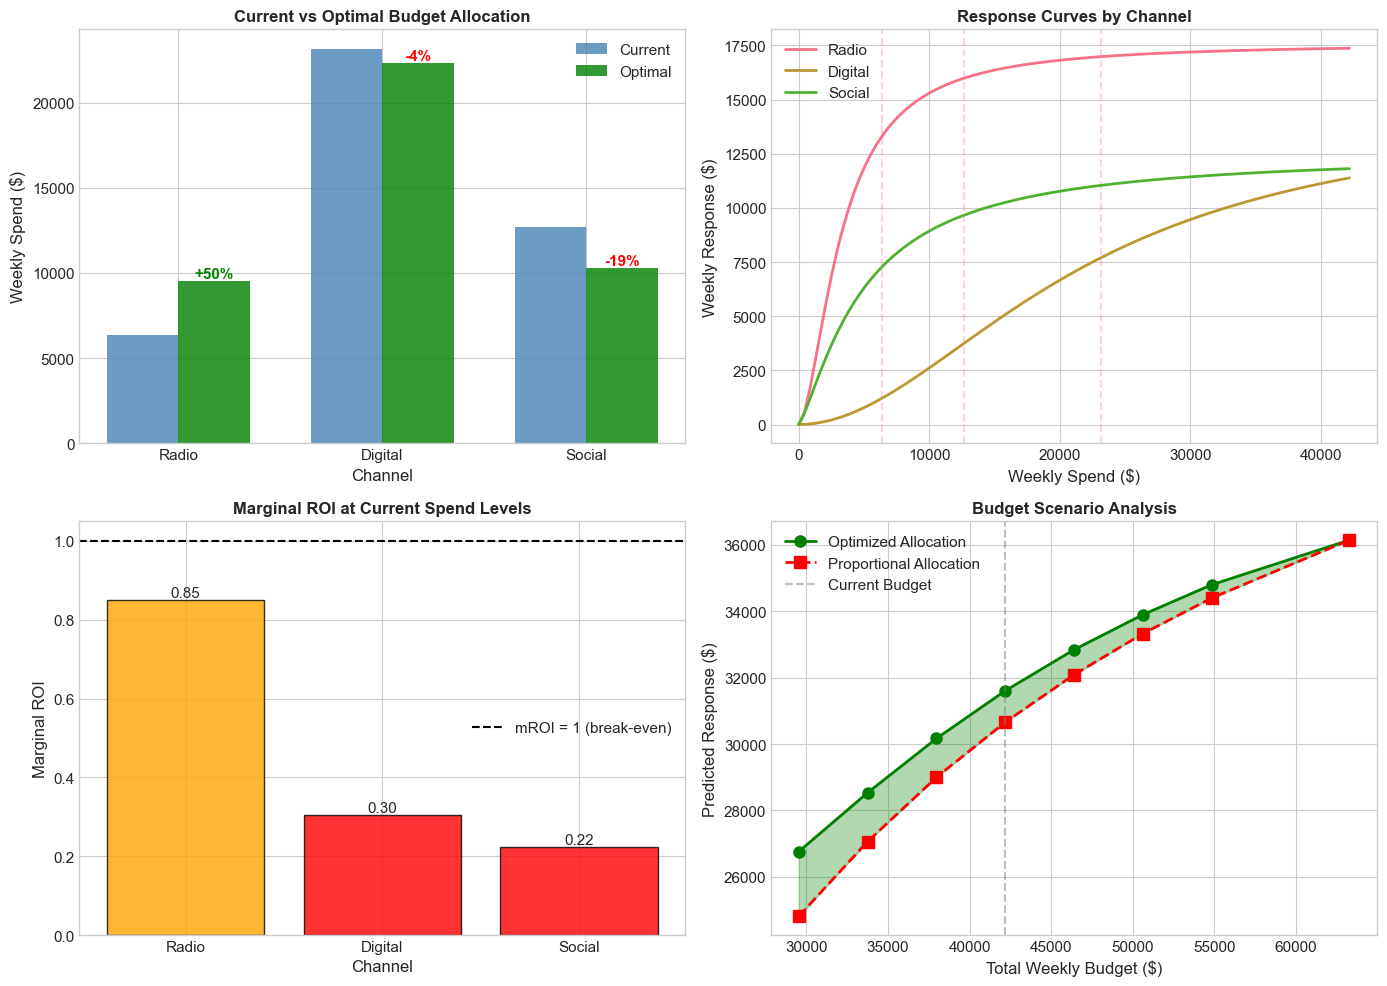


 INSIGHTS:
------------------------------------------------------------
• Channels with mROI > 1 are still profitable at current spend
• Consider reallocating from low mROI to high mROI channels
• The gap between optimized and proportional lines shows the value of smart allocation


In [21]:
# Visualization of optimization results

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Current vs Optimal Allocation
channels = [col.replace('_spend', '').title() for col in MEDIA_COLS]
x = np.arange(len(channels))
width = 0.35

axes[0, 0].bar(x - width/2, current_spend, width, label='Current', color='steelblue', alpha=0.8)
axes[0, 0].bar(x + width/2, opt_result['optimal_allocation'], width, label='Optimal', color='green', alpha=0.8)
axes[0, 0].set_xlabel('Channel')
axes[0, 0].set_ylabel('Weekly Spend ($)')
axes[0, 0].set_title('Current vs Optimal Budget Allocation', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(channels)
axes[0, 0].legend()

# Add change annotations
for i in range(len(channels)):
    change = (opt_result['optimal_allocation'][i] - current_spend[i]) / current_spend[i] * 100
    color = 'green' if change > 0 else 'red'
    axes[0, 0].annotate(f'{change:+.0f}%', 
                        xy=(x[i] + width/2, opt_result['optimal_allocation'][i]),
                        ha='center', va='bottom', color=color, fontweight='bold')

# 2. Response Curves
spend_range = np.linspace(0, current_budget, 100)
params = bayesian_mmm.params

for i, channel in enumerate(channels):
    response = []
    for spend in spend_range:
        decay = params['decay'][i]
        effective_spend = spend / (1 - decay)
        K = params['K'][i]
        alpha = params['alpha'][i]
        sat = hill_saturation(effective_spend, K, alpha)
        response.append(params['beta'][i] * sat)
    
    axes[0, 1].plot(spend_range, response, label=channel, linewidth=2)
    # Mark current spend
    axes[0, 1].axvline(x=current_spend[i], linestyle='--', alpha=0.3)

axes[0, 1].set_xlabel('Weekly Spend ($)')
axes[0, 1].set_ylabel('Weekly Response ($)')
axes[0, 1].set_title('Response Curves by Channel', fontsize=12, fontweight='bold')
axes[0, 1].legend()

# 3. Marginal ROI at current spend
marginal_roi = []
delta = 100  # $100 increment

for i in range(len(MEDIA_COLS)):
    # Current response
    decay = params['decay'][i]
    K = params['K'][i]
    alpha = params['alpha'][i]
    
    current = current_spend[i]
    effective_current = current / (1 - decay)
    response_current = params['beta'][i] * hill_saturation(effective_current, K, alpha)
    
    # Response with increment
    effective_plus = (current + delta) / (1 - decay)
    response_plus = params['beta'][i] * hill_saturation(effective_plus, K, alpha)
    
    mroi = (response_plus - response_current) / delta
    marginal_roi.append(mroi)

colors = ['green' if mr > 1 else 'orange' if mr > 0.5 else 'red' for mr in marginal_roi]
axes[1, 0].bar(channels, marginal_roi, color=colors, alpha=0.8, edgecolor='black')
axes[1, 0].axhline(y=1, color='black', linestyle='--', label='mROI = 1 (break-even)')
axes[1, 0].set_xlabel('Channel')
axes[1, 0].set_ylabel('Marginal ROI')
axes[1, 0].set_title('Marginal ROI at Current Spend Levels', fontsize=12, fontweight='bold')
axes[1, 0].legend()

for i, mr in enumerate(marginal_roi):
    axes[1, 0].annotate(f'{mr:.2f}', xy=(i, mr), ha='center', va='bottom')

# 4. Scenario analysis visualization
axes[1, 1].plot(scenario_df['Total Budget'], scenario_df['Optimal Response'], 
                'go-', label='Optimized Allocation', linewidth=2, markersize=8)
axes[1, 1].plot(scenario_df['Total Budget'], scenario_df['Proportional Response'], 
                'rs--', label='Proportional Allocation', linewidth=2, markersize=8)
axes[1, 1].axvline(x=current_budget, color='gray', linestyle='--', alpha=0.5, label='Current Budget')
axes[1, 1].set_xlabel('Total Weekly Budget ($)')
axes[1, 1].set_ylabel('Predicted Response ($)')
axes[1, 1].set_title('Budget Scenario Analysis', fontsize=12, fontweight='bold')
axes[1, 1].legend()

# Fill between to show optimization gain
axes[1, 1].fill_between(scenario_df['Total Budget'], 
                        scenario_df['Proportional Response'],
                        scenario_df['Optimal Response'],
                        alpha=0.3, color='green', label='Optimization Gain')

plt.tight_layout()
plt.show()

print("\n INSIGHTS:")
print("-" * 60)
print("• Channels with mROI > 1 are still profitable at current spend")
print("• Consider reallocating from low mROI to high mROI channels")
print("• The gap between optimized and proportional lines shows the value of smart allocation")

---

# Section 12: Advanced Topics - Time-Varying Parameters and Hierarchical Models

## 12.1 Time-Varying Effects

In practice, marketing effectiveness changes over time due to:
- **Creative Fatigue**: Same ad becomes less effective over time
- **Market Dynamics**: Competition, economic conditions
- **Seasonality in Effectiveness**: Ads work differently in different seasons
- **Platform Changes**: Algorithm updates (Facebook, Google)

### Approaches:
1. **Rolling Window Models**: Fit separate models for each time window
2. **Regime-Switching Models**: Allow parameters to switch between states
3. **State-Space Models**: Parameters evolve as random walks
4. **Bayesian Structural Time Series**: Flexible trend + seasonality + effects

---

## 12.2 Hierarchical (Multi-Level) Models

When you have data across multiple **groups** (regions, products, brands), hierarchical models allow:
- **Partial Pooling**: Borrow strength across groups
- **Group-Specific Effects**: While maintaining overall structure
- **Better Small Sample Performance**: Essential when some groups have little data

### Model Structure:

$$Y_{g,t} = \beta_{0,g} + \sum_c \beta_{c,g} \cdot f(X_{c,g,t}) + \epsilon_{g,t}$$

Where:
$$\beta_{c,g} \sim N(\mu_{\beta_c}, \sigma_{\beta_c}^2)$$

The group-level effects $\beta_{c,g}$ are drawn from a shared distribution, allowing information sharing.

---

## 12.3 When to Use Advanced Models

| Scenario | Recommended Approach |
|----------|---------------------|
| 3+ years of data, stable market | Standard model |
| Major market disruption (COVID) | Time-varying or regime-switching |
| Multi-region business | Hierarchical model |
| Multiple products/brands | Hierarchical model |
| Fast-changing digital landscape | Rolling window or time-varying |
| Small data per segment | Hierarchical (for pooling) |

 TIME-VARYING EFFECTS ANALYSIS (Rolling Window)

Fitting models on rolling 52-week windows...

 Fitted 8 rolling window models


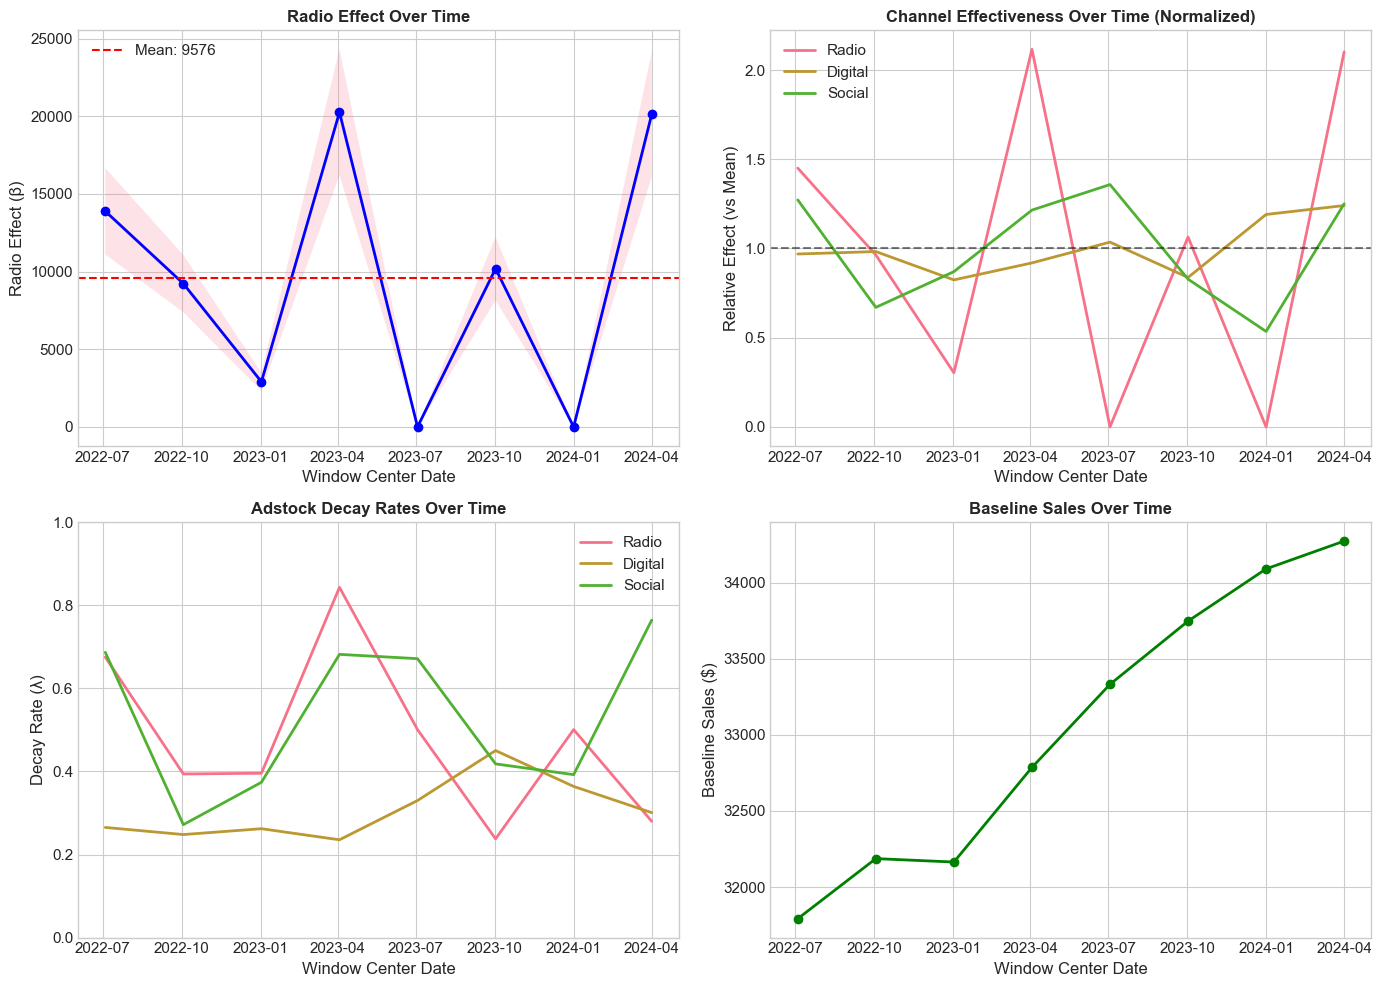


 PARAMETER STABILITY ANALYSIS
------------------------------------------------------------

Coefficient of Variation (CV) by Parameter:
(Lower CV = More stable over time)

  Radio           Effect: CV = 85.8% (Variable)
  Digital         Effect: CV = 15.1% (Stable)
  Social          Effect: CV = 31.2% (Moderate)


In [22]:
# Advanced Topic: Rolling Window Analysis for Time-Varying Effects

def rolling_mmm_analysis(df, media_cols, control_cols, window_size=52, step_size=13):
    """
    Fit MMM on rolling windows to detect time-varying effects.
    
    Parameters:
    -----------
    df : DataFrame
        Full dataset
    window_size : int
        Size of rolling window (in weeks)
    step_size : int
        Step size between windows
        
    Returns:
    --------
    DataFrame : Parameter estimates over time
    """
    results = []
    
    for start in range(0, len(df) - window_size, step_size):
        end = start + window_size
        window_df = df.iloc[start:end].copy()
        
        # Fit model on window
        window_mmm = BayesianMMM(n_channels=len(media_cols))
        
        media_data = window_df[media_cols].values
        control_data = window_df[control_cols].values
        y = window_df['sales'].values
        
        try:
            window_mmm.fit(media_data, control_data, y, n_restarts=2)
            
            result = {
                'window_start': window_df['date'].iloc[0],
                'window_end': window_df['date'].iloc[-1],
                'window_center': window_df['date'].iloc[window_size//2],
                'baseline': window_mmm.params['baseline']
            }
            
            for i, col in enumerate(media_cols):
                channel = col.replace('_spend', '')
                result[f'{channel}_decay'] = window_mmm.params['decay'][i]
                result[f'{channel}_beta'] = window_mmm.params['beta'][i]
            
            results.append(result)
        except:
            continue
    
    return pd.DataFrame(results)

print("=" * 70)
print(" TIME-VARYING EFFECTS ANALYSIS (Rolling Window)")
print("=" * 70)
print("\nFitting models on rolling 52-week windows...\n")

rolling_results = rolling_mmm_analysis(df, MEDIA_COLS, CONTROL_COLS, window_size=52, step_size=13)

if len(rolling_results) > 0:
    print(f" Fitted {len(rolling_results)} rolling window models")
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Radio effect over time
    if 'radio_beta' in rolling_results.columns:
        axes[0, 0].plot(rolling_results['window_center'], rolling_results['radio_beta'], 
                        'b-o', linewidth=2, markersize=6)
        axes[0, 0].fill_between(rolling_results['window_center'], 
                                rolling_results['radio_beta'] * 0.8,
                                rolling_results['radio_beta'] * 1.2, alpha=0.2)
        axes[0, 0].set_xlabel('Window Center Date')
        axes[0, 0].set_ylabel('Radio Effect (β)')
        axes[0, 0].set_title('Radio Effect Over Time', fontsize=12, fontweight='bold')
        axes[0, 0].axhline(y=rolling_results['radio_beta'].mean(), color='r', linestyle='--', 
                          label=f'Mean: {rolling_results["radio_beta"].mean():.0f}')
        axes[0, 0].legend()
    
    # 2. All channel effects
    for col in MEDIA_COLS:
        channel = col.replace('_spend', '')
        beta_col = f'{channel}_beta'
        if beta_col in rolling_results.columns:
            # Normalize to show relative change
            normalized = rolling_results[beta_col] / rolling_results[beta_col].mean()
            axes[0, 1].plot(rolling_results['window_center'], normalized, 
                           label=channel.title(), linewidth=2)
    
    axes[0, 1].axhline(y=1, color='black', linestyle='--', alpha=0.5)
    axes[0, 1].set_xlabel('Window Center Date')
    axes[0, 1].set_ylabel('Relative Effect (vs Mean)')
    axes[0, 1].set_title('Channel Effectiveness Over Time (Normalized)', fontsize=12, fontweight='bold')
    axes[0, 1].legend()
    
    # 3. Decay rates over time
    for col in MEDIA_COLS:
        channel = col.replace('_spend', '')
        decay_col = f'{channel}_decay'
        if decay_col in rolling_results.columns:
            axes[1, 0].plot(rolling_results['window_center'], rolling_results[decay_col], 
                           label=channel.title(), linewidth=2)
    
    axes[1, 0].set_xlabel('Window Center Date')
    axes[1, 0].set_ylabel('Decay Rate (λ)')
    axes[1, 0].set_title('Adstock Decay Rates Over Time', fontsize=12, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].set_ylim(0, 1)
    
    # 4. Baseline over time
    axes[1, 1].plot(rolling_results['window_center'], rolling_results['baseline'], 
                    'g-o', linewidth=2, markersize=6)
    axes[1, 1].set_xlabel('Window Center Date')
    axes[1, 1].set_ylabel('Baseline Sales ($)')
    axes[1, 1].set_title('Baseline Sales Over Time', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\n PARAMETER STABILITY ANALYSIS")
    print("-" * 60)
    print("\nCoefficient of Variation (CV) by Parameter:")
    print("(Lower CV = More stable over time)")
    print()
    
    for col in MEDIA_COLS:
        channel = col.replace('_spend', '')
        beta_col = f'{channel}_beta'
        if beta_col in rolling_results.columns:
            cv = rolling_results[beta_col].std() / rolling_results[beta_col].mean() * 100
            stability = "Stable" if cv < 20 else "Moderate" if cv < 40 else "Variable"
            print(f"  {channel.title():15} Effect: CV = {cv:.1f}% ({stability})")
else:
    print("  Not enough data for rolling window analysis")

In [23]:
# Hierarchical Model Structure (Pseudocode/Framework)
# This shows the structure for a multi-region hierarchical MMM

print("=" * 70)
print(" HIERARCHICAL MMM ARCHITECTURE")
print("=" * 70)

hierarchical_code = '''
# Hierarchical MMM with PyMC (Pseudocode)
# Use this as a template for production implementation

import pymc as pm
import pytensor.tensor as pt

def build_hierarchical_mmm(media_data, control_data, y, geo_idx, n_geos):
    """
    Build a hierarchical Bayesian MMM with partial pooling across geographies.
    
    Parameters:
    -----------
    media_data : array (n_obs, n_channels)
        Media spend data
    control_data : array (n_obs, n_controls)
        Control variables
    y : array (n_obs,)
        Target (sales)
    geo_idx : array (n_obs,)
        Geographic index for each observation
    n_geos : int
        Number of geographic regions
    """
    n_obs, n_channels = media_data.shape
    n_controls = control_data.shape[1]
    
    with pm.Model() as hierarchical_model:
        
        # ========== HYPERPRIORS (Population-Level) ==========
        
        # Population mean for decay rates
        mu_decay = pm.Beta('mu_decay', alpha=2, beta=2, shape=n_channels)
        kappa_decay = pm.HalfNormal('kappa_decay', sigma=10, shape=n_channels)
        
        # Population mean for effect sizes
        mu_beta = pm.HalfNormal('mu_beta', sigma=10000, shape=n_channels)
        sigma_beta = pm.HalfNormal('sigma_beta', sigma=5000, shape=n_channels)
        
        # ========== GEO-LEVEL PARAMETERS ==========
        
        # Geo-specific decay rates (partial pooling)
        alpha_decay = mu_decay * kappa_decay
        beta_decay = (1 - mu_decay) * kappa_decay
        decay = pm.Beta('decay', alpha=alpha_decay, beta=beta_decay, 
                       shape=(n_geos, n_channels))
        
        # Geo-specific effect sizes (partial pooling)
        beta = pm.TruncatedNormal('beta', mu=mu_beta, sigma=sigma_beta,
                                  lower=0, shape=(n_geos, n_channels))
        
        # Geo-specific baselines
        baseline = pm.Normal('baseline', mu=50000, sigma=10000, shape=n_geos)
        
        # ========== SATURATION PARAMETERS (shared) ==========
        
        # Half-saturation points (can also be hierarchical)
        K = pm.LogNormal('K', mu=np.log(30000), sigma=0.5, shape=n_channels)
        alpha = pm.LogNormal('alpha_sat', mu=np.log(1.5), sigma=0.3, shape=n_channels)
        
        # ========== TRANSFORMATIONS ==========
        
        # Apply adstock (vectorized for all geos)
        def apply_adstock_geo(x, decay_geo):
            # Custom scan for geometric adstock
            # Implementation depends on pytensor
            pass
        
        # Apply Hill saturation
        def apply_saturation(x, K, alpha):
            return (x ** alpha) / (K ** alpha + x ** alpha)
        
        # ========== LIKELIHOOD ==========
        
        # Compute predictions for each geo
        # mu = baseline[geo_idx] + sum(beta[geo_idx, c] * transformed_media[c])
        
        # Observation noise
        sigma = pm.HalfNormal('sigma', sigma=5000)
        
        # Likelihood
        y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)
    
    return hierarchical_model

# To fit:
# with hierarchical_model:
#     trace = pm.sample(1000, tune=1000, cores=4)
'''

print(hierarchical_code)

print("\n" + "=" * 70)
print(" KEY BENEFITS OF HIERARCHICAL MODELS")
print("=" * 70)
print("""
1. PARTIAL POOLING
   - Geo with little data "borrows" from similar geos
   - Prevents overfitting in small segments
   - More stable estimates overall

2. SHRINKAGE
   - Extreme estimates are pulled toward population mean
   - Acts as intelligent regularization

3. UNCERTAINTY PROPAGATION  
   - Uncertainty in population parameters flows to geo-level
   - More honest confidence intervals

4. EFFICIENCY
   - One model instead of N separate models
   - Faster iteration and deployment

5. TRANSFER LEARNING
   - New geos can use population priors
   - Enables predictions for markets without historical data
""")

 HIERARCHICAL MMM ARCHITECTURE

# Hierarchical MMM with PyMC (Pseudocode)
# Use this as a template for production implementation

import pymc as pm
import pytensor.tensor as pt

def build_hierarchical_mmm(media_data, control_data, y, geo_idx, n_geos):
    """
    Build a hierarchical Bayesian MMM with partial pooling across geographies.

    Parameters:
    -----------
    media_data : array (n_obs, n_channels)
        Media spend data
    control_data : array (n_obs, n_controls)
        Control variables
    y : array (n_obs,)
        Target (sales)
    geo_idx : array (n_obs,)
        Geographic index for each observation
    n_geos : int
        Number of geographic regions
    """
    n_obs, n_channels = media_data.shape
    n_controls = control_data.shape[1]

    with pm.Model() as hierarchical_model:

        # ========== HYPERPRIORS (Population-Level) ==========

        # Population mean for decay rates
        mu_decay = pm.Beta('mu_decay', alpha=2, beta=2, shape=n_channels)
 

---

# Section 14: Summary and Key Takeaways

### 1. **Theoretical Foundations**
- MMM uses regression to quantify marketing impact on business outcomes
- The fundamental equation: $Y = \beta_0 + \sum \beta_i \cdot f(X_i) + \text{controls} + \epsilon$
- Key transformations: Adstock (carryover) and Saturation (diminishing returns)

### 2. **Adstock Transformation**
- Captures the persistence of advertising effects over time
- Geometric decay: $\text{Adstock}_t = X_t + \lambda \cdot \text{Adstock}_{t-1}$
- Half-life = $\frac{-\ln(2)}{\ln(\lambda)}$

### 3. **Saturation (Hill Function)**
- Models diminishing returns at higher spend levels
- $f(x) = \frac{x^\alpha}{K^\alpha + x^\alpha}$
- K = half-saturation point, α = shape

### 4. **Modeling Approaches**
- **Frequentist (OLS)**: Fast, interpretable, but point estimates only
- **Bayesian**: Uncertainty quantification, prior incorporation, hierarchical models

### 5. **Model Validation**
- Out-of-sample prediction on holdout set
- Time series cross-validation
- Residual diagnostics
- Comparison with experiments (lift tests)

### 6. **Business Applications**
- Contribution analysis: Decompose sales by driver
- ROI calculation: Revenue per dollar spent
- Budget optimization: Reallocate for maximum impact

### 7. **Advanced Topics**
- Time-varying parameters for evolving markets
- Hierarchical models for multi-region businesses
- Two-sided marketplace considerations

---

1. **Why Bayesian?** Uncertainty quantification, prior incorporation, better for small samples

2. **Adstock vs. Saturation**: Adstock = TIME dimension (carryover), Saturation = SPEND dimension (diminishing returns)

3. **Model Validation**: Never trust in-sample fit alone; use time-based holdout and CV

4. **Multicollinearity**: Marketing channels are often correlated; use ridge/Bayesian priors

5. **Incrementality**: MMM estimates correlation → use experiments to validate causation

6. **Two-Sided Markets**: Model both sides, account for cross-side effects and network effects

---

## Recommended Resources

### Papers:
- Jin et al. (2017) - "Bayesian Methods for Media Mix Modeling with Carryover and Shape Effects" (Google)
- Sun et al. (2017) - "Geo-level Bayesian Hierarchical Media Mix Modeling" (Google)

### Tools:
- **Google Meridian**: Latest Google MMM (successor to LightweightMMM)
- **PyMC-Marketing**: Bayesian MMM in Python
- **Orbit**: Uber's time series forecasting library

### Books:
- "Bayesian Data Analysis" by Gelman et al.
- "Statistical Rethinking" by Richard McElreath

In [ ]:
# Final Summary: Complete MMM Pipeline Overview

print("=" * 80)
print(" COMPLETE MMM PIPELINE - IMPLEMENTATION CHECKLIST")
print("=" * 80)

pipeline_stages = {
    "1. DATA COLLECTION & PREPARATION": [
        " Gather media spend data (by channel, by time period)",
        " Collect outcome data (sales, conversions, revenue)",
        " Identify control variables (price, promotions, seasonality, external factors)",
        " Align all data to consistent time granularity (daily/weekly)",
        " Handle missing values and outliers",
        " Create derived features (trend, Fourier terms for seasonality)"
    ],
    "2. EXPLORATORY DATA ANALYSIS": [
        " Visualize time series of target and media variables",
        " Check correlation matrix for multicollinearity",
        " Identify seasonality patterns and anomalies",
        " Analyze spend distribution and potential saturation"
    ],
    "3. FEATURE ENGINEERING": [
        " Apply adstock transformation (estimate or optimize decay rates)",
        " Apply saturation transformation (Hill function or log)",
        " Scale variables appropriately (divide by mean is common)",
        " Create control features (holidays, events, trend)"
    ],
    "4. MODEL SPECIFICATION & FITTING": [
        " Choose modeling approach (OLS, Bayesian)",
        " Set priors based on domain knowledge (for Bayesian)",
        " Fit model with appropriate number of samples/chains",
        " Check convergence (R-hat, trace plots)"
    ],
    "5. MODEL VALIDATION": [
        " Evaluate in-sample fit (R², MAPE, residuals)",
        " Out-of-sample prediction on holdout set",
        " Time series cross-validation",
        " Compare with benchmark/baseline models",
        " Calibrate against experiments/lift tests if available"
    ],
    "6. CONTRIBUTION ANALYSIS": [
        " Decompose sales into baseline + media + controls",
        " Calculate total contribution by channel",
        " Compute contribution shares",
        " Visualize contributions over time (stacked area)"
    ],
    "7. ROI & EFFICIENCY ANALYSIS": [
        " Calculate total ROI per channel (contribution / spend)",
        " Calculate marginal ROI (derivative at current spend)",
        " Identify over/under-invested channels",
        " Generate response curves"
    ],
    "8. BUDGET OPTIMIZATION": [
        " Define objective (maximize sales, profit, or custom)",
        " Set constraints (total budget, min/max per channel)",
        " Run optimization (SLSQP, differential evolution)",
        " Analyze scenarios (budget up/down X%)"
    ],
    "9. REPORTING & COMMUNICATION": [
        " Create executive summary with key findings",
        " Visualize channel effectiveness and recommendations",
        " Document model assumptions and limitations",
        " Provide confidence intervals and uncertainty ranges"
    ],
    "10. PRODUCTION & MAINTENANCE": [
        " Set up automated data pipeline",
        " Implement model refresh schedule (monthly/quarterly)",
        " Monitor model performance drift",
        " Incorporate new data and retrain"
    ]
}

for stage, items in pipeline_stages.items():
    print(f"\n{stage}")
    print("-" * 60)
    for item in items:
        print(f"  {item}")

print("\n" + "=" * 80)
print(" CONGRATULATIONS!")
print("=" * 80)
print("""
You've completed a comprehensive journey through Marketing Mix Modeling!

You now understand:
• The theory and mathematics behind MMM
• How to implement adstock and saturation transformations
• Building both frequentist (OLS) and Bayesian MMM
• Model validation and diagnostics
• Contribution analysis and ROI calculation
• Budget optimization techniques
• Advanced topics like time-varying effects and hierarchical models

""")

# Final metrics summary
print("\n" + "=" * 80)
print(" MODEL PERFORMANCE SUMMARY")
print("=" * 80)
print(f"\n{'Model':<20} {'Train MAPE':>15} {'Test MAPE':>15} {'Train R²':>12}")
print("-" * 62)
print(f"{'OLS':<20} {mape:>14.1f}% {mean_absolute_percentage_error(test_y, test_pred_ols)*100:>14.1f}% {r2:>11.3f}")
print(f"{'Bayesian':<20} {mape_bayes:>14.1f}% {mean_absolute_percentage_error(test_y, test_pred_bayes)*100:>14.1f}% {r2_bayes:>11.3f}")